In [1]:
# === Cell 1: Load all completed results ===

import numpy as np
import glob
import os
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
sns.set_context("paper", font_scale=1.2)

RESULTS_DIR = "../results_re2d"
DATA_DIR = "../bmDCA"

# Auto-discover all completed .npz files
npz_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_re2d.npz")))
print(f"Found {len(npz_files)} completed pair(s):")

results = {}
for f in npz_files:
    d = np.load(f, allow_pickle=True)
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    key = f"{pf1}_{pf2}"
    results[key] = d
    ovs = d['overlap_lengths']
    ov0 = ovs[0]
    grid_shape = d[f'z_mean_{ov0}'].shape
    cfg = str(d['config'])
    print(f"  {pf1} x {pf2}: grid={grid_shape}, overlaps={list(ovs)}")

# Also count checkpoint-only pairs
pkl_files = glob.glob(os.path.join(RESULTS_DIR, "*_checkpoint.pkl"))
pkl_pairs = set()
for f in pkl_files:
    name = os.path.basename(f).replace('_checkpoint.pkl', '')
    if name not in results:
        pkl_pairs.add(name)
print(f"\n{len(pkl_pairs)} pair(s) still in progress (checkpoint only)")
print(f"{66 - len(results) - len(pkl_pairs)} pair(s) with no output")

Found 5 completed pair(s):
  PF00004 x PF00041: grid=(8, 8), overlaps=[np.int64(216), np.int64(215), np.int64(214)]
  PF00041 x PF00096: grid=(40, 40), overlaps=[np.int64(63), np.int64(62), np.int64(61)]
  PF00041 x PF00595: grid=(40, 40), overlaps=[np.int64(207), np.int64(206), np.int64(205)]
  PF00072 x PF00153: grid=(40, 40), overlaps=[np.int64(249), np.int64(248), np.int64(247)]
  PF00271 x PF02518: grid=(40, 40), overlaps=[np.int64(279), np.int64(278), np.int64(277)]

50 pair(s) still in progress (checkpoint only)
11 pair(s) with no output


In [2]:
# === Cell 2: Load natural energies for all protein families ===

import sys
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from overlappingGenes import load_natural_energies

# Collect all PF names that appear in results
pf_names = set()
for key in results:
    d = results[key]
    pf_names.add(str(d['pf1']))
    pf_names.add(str(d['pf2']))

nat_energies = {}
nat_stats = {}
for pf in sorted(pf_names):
    nat_file = os.path.join(DATA_DIR, pf, f"{pf}_naturalenergies.txt")
    if os.path.exists(nat_file):
        e = np.array(load_natural_energies(nat_file))
        nat_energies[pf] = e
        nat_stats[pf] = (float(np.mean(e)), float(np.std(e)))
        print(f"{pf}: mean={nat_stats[pf][0]:.2f}, std={nat_stats[pf][1]:.2f}, n={len(e)}")
    else:
        print(f"{pf}: natural energies file not found")

PF00004: mean=145.88, std=38.25, n=213960
PF00041: mean=120.66, std=17.64, n=701132
PF00072: mean=201.37, std=29.97, n=462794
PF00096: mean=16.44, std=5.23, n=2002299
PF00153: mean=92.55, std=25.62, n=283540
PF00271: mean=149.58, std=27.18, n=325812
PF00595: mean=87.53, std=17.89, n=293904
PF02518: mean=186.84, std=26.05, n=384164


In [3]:
# === Cell 3: Summary table ===

import pandas as pd

rows = []
for key, d in results.items():
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    for ov in d['overlap_lengths']:
        ov = int(ov)
        z_mean = d[f'z_mean_{ov}']
        wass_mean = d[f'wass_mean_{ov}']
        T1 = d[f'T1_fine_{ov}']
        T2 = d[f'T2_fine_{ov}']

        z_min_idx = np.unravel_index(np.argmin(z_mean), z_mean.shape)
        w_min_idx = np.unravel_index(np.argmin(wass_mean), wass_mean.shape)

        rows.append({
            'Pair': f"{pf1} x {pf2}",
            'Overlap (nt)': ov,
            'Frame': ov % 3,
            'Grid': f"{z_mean.shape[0]}x{z_mean.shape[1]}",
            'Best Z': f"{z_mean.min():.3f}",
            'Z @ T1': f"{T1[z_min_idx[1]]:.3f}",
            'Z @ T2': f"{T2[z_min_idx[0]]:.3f}",
            'Best W': f"{wass_mean.min():.2f}",
            'W @ T1': f"{T1[w_min_idx[1]]:.3f}",
            'W @ T2': f"{T2[w_min_idx[0]]:.3f}",
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

             Pair  Overlap (nt)  Frame  Grid Best Z Z @ T1 Z @ T2 Best W W @ T1 W @ T2
PF00004 x PF00041           216      0   8x8  0.850  0.200  0.200  23.89  0.571  0.571
PF00004 x PF00041           215      2   8x8  0.831  0.386  0.571  19.16  0.386  0.571
PF00004 x PF00041           214      1   8x8  1.497  0.386  0.386  28.30  0.386  0.386
PF00041 x PF00096            63      0 40x40  0.900  0.833  0.500   3.45  0.833  0.500
PF00041 x PF00096            62      2 40x40  1.059  0.833  0.767   3.01  0.833  0.800
PF00041 x PF00096            61      1 40x40  1.049  0.767  0.600   2.94  0.800  0.700
PF00041 x PF00595           207      0 40x40  0.568  0.600  0.600   8.91  0.633  0.633
PF00041 x PF00595           206      2 40x40  0.614  0.667  0.633   8.50  0.700  0.667
PF00041 x PF00595           205      1 40x40  1.746  0.333  0.300  17.97  0.367  0.333
PF00072 x PF00153           249      0 40x40  0.768  0.233  0.200  20.92  0.467  0.433
PF00072 x PF00153           248      2 40x4

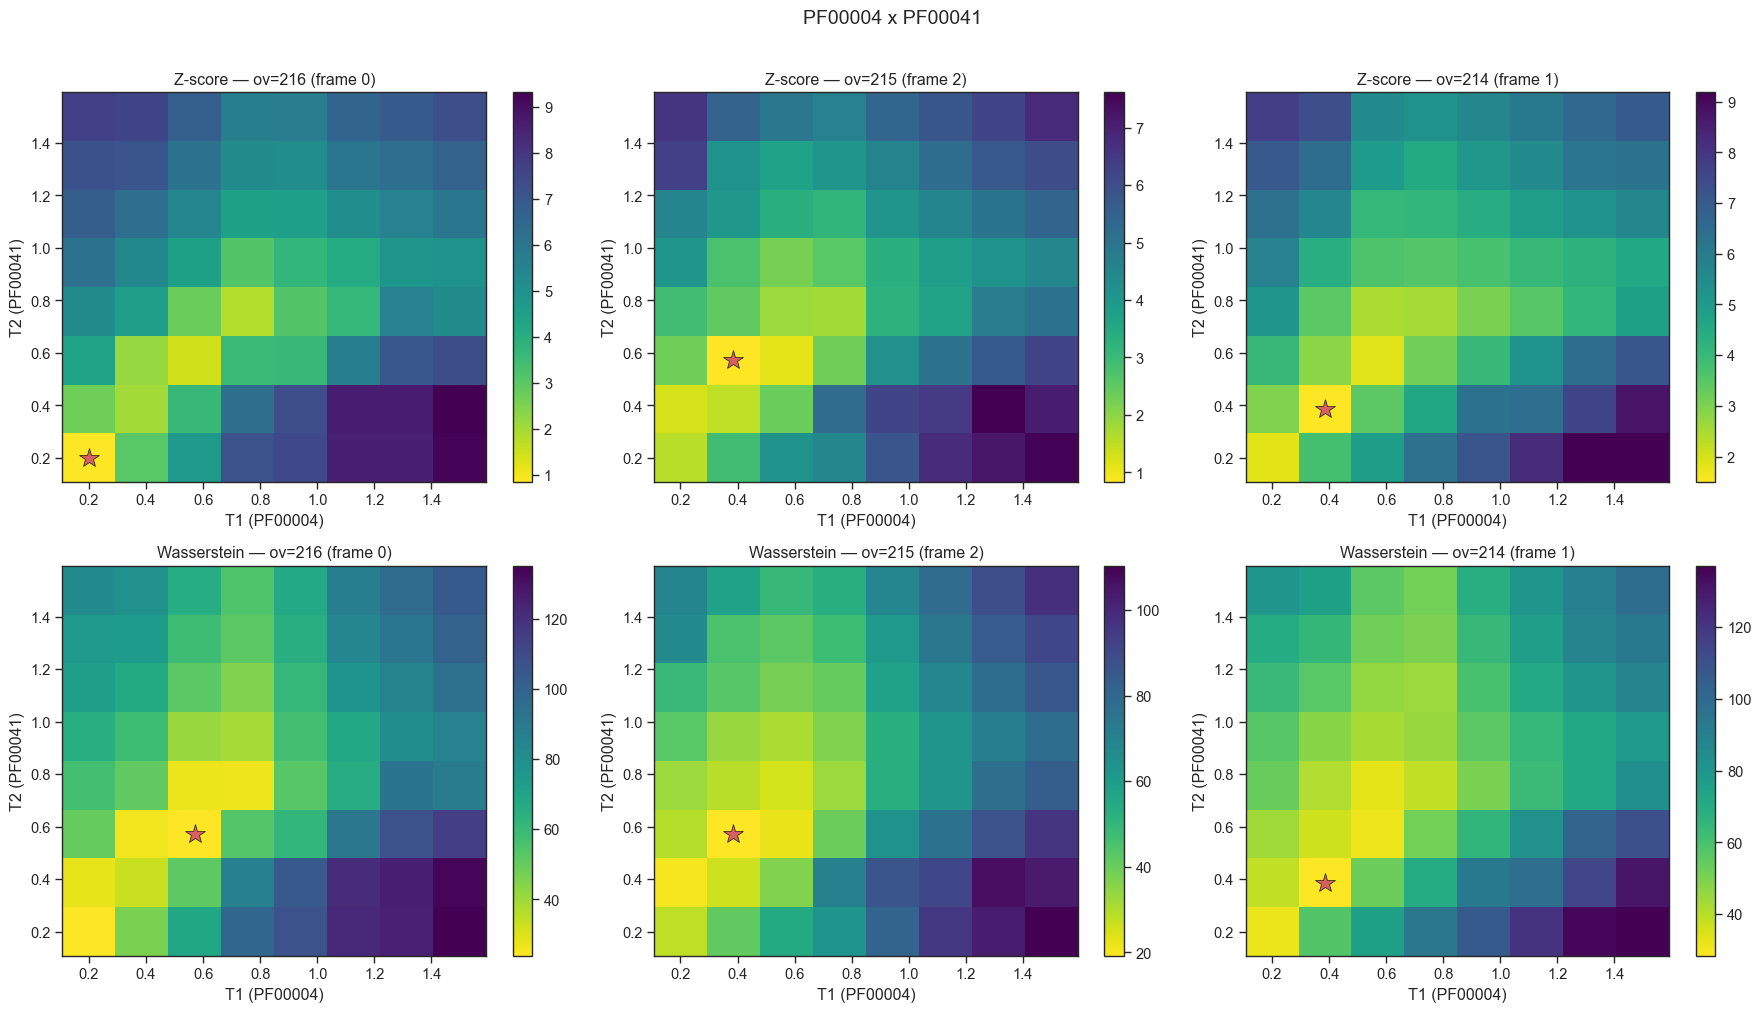

Saved PF00004_PF00041_heatmaps.png


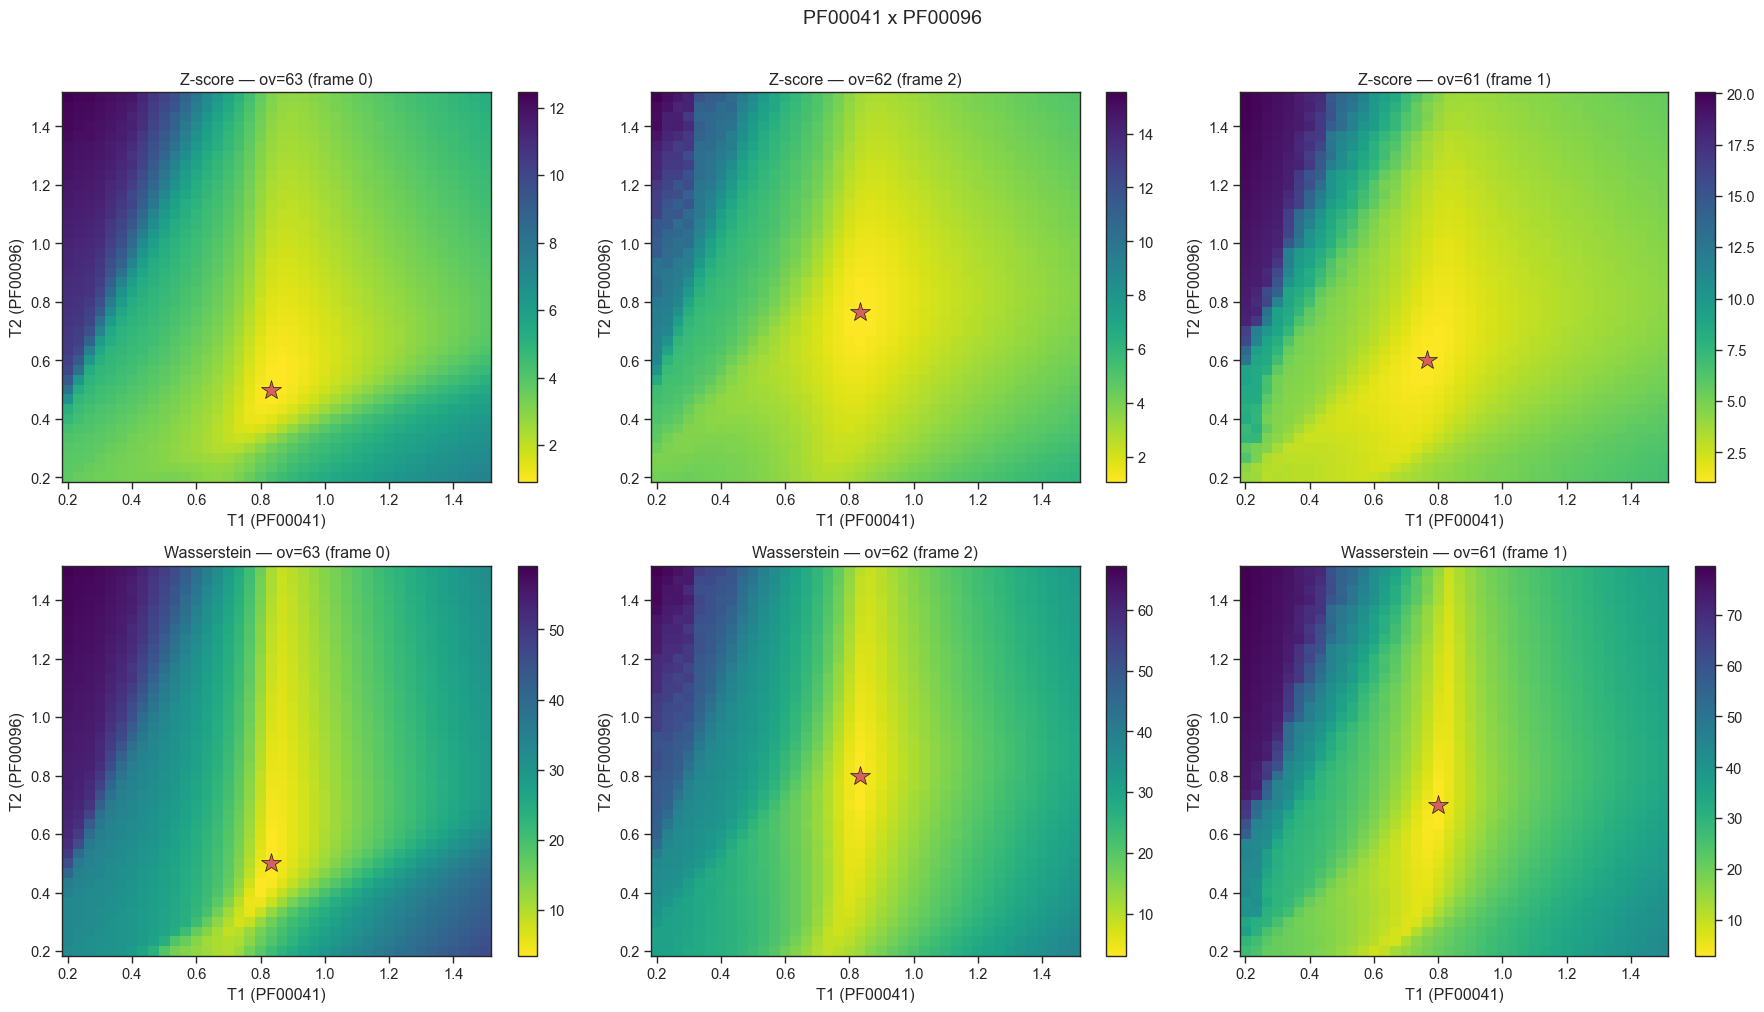

Saved PF00041_PF00096_heatmaps.png


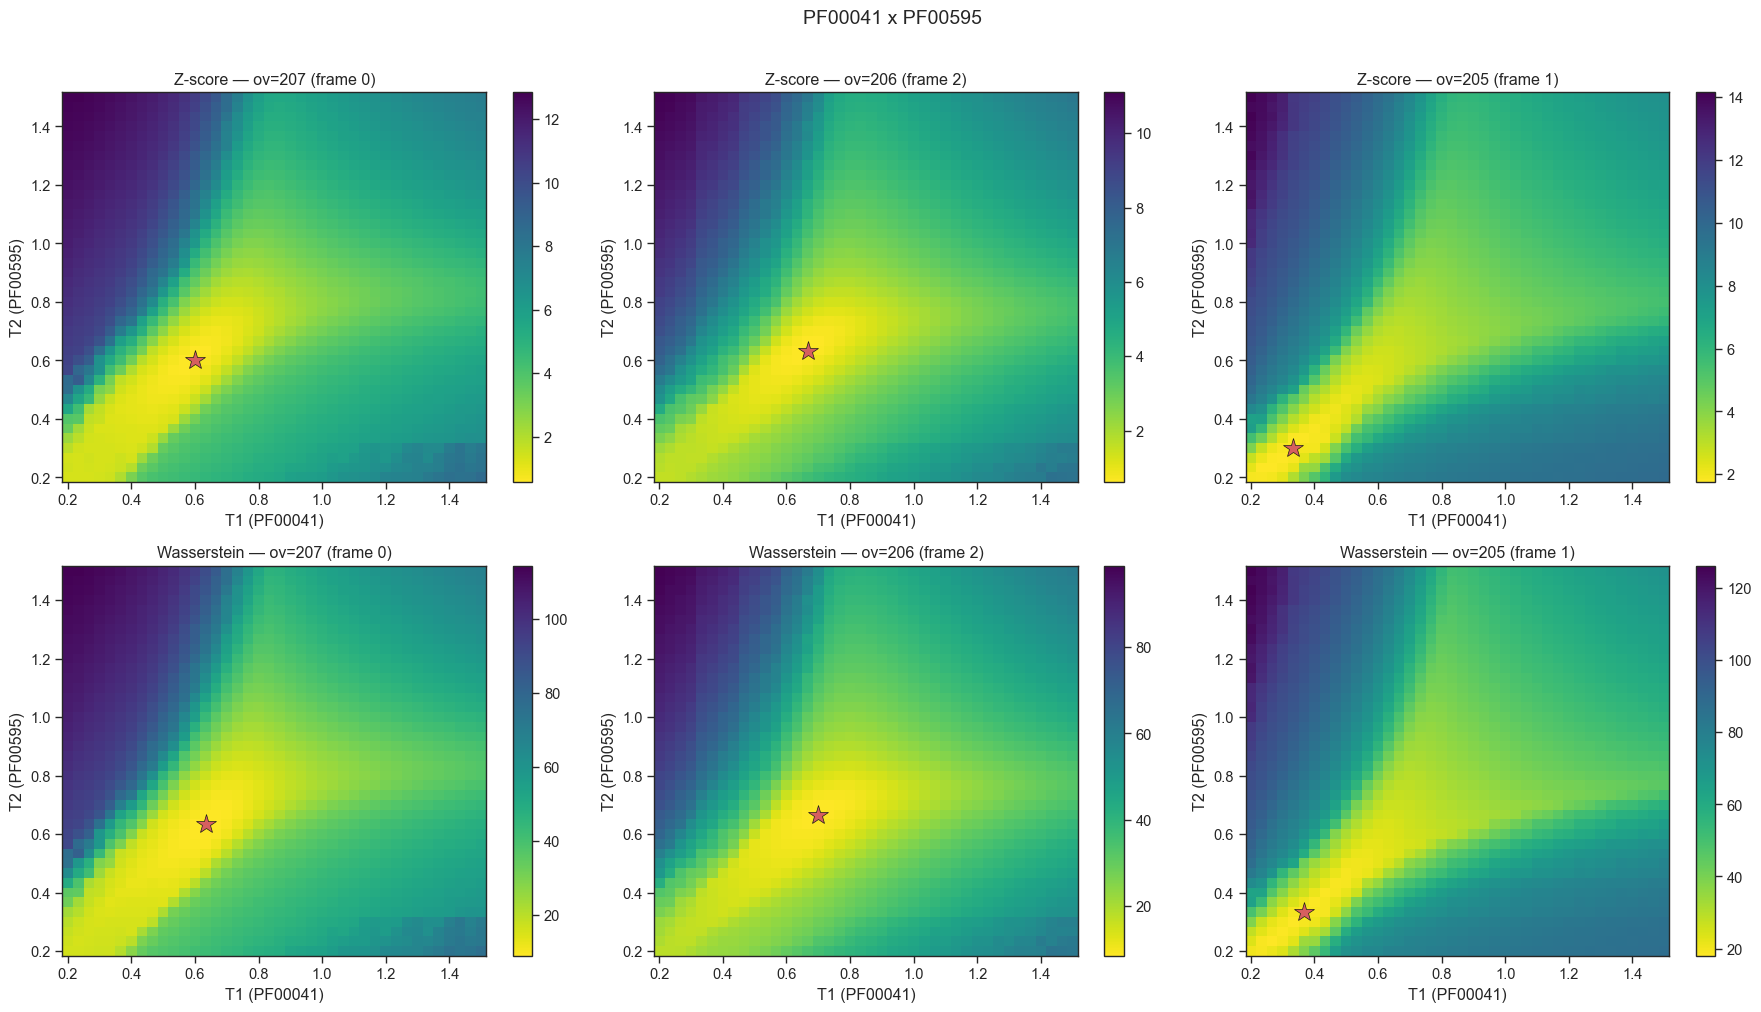

Saved PF00041_PF00595_heatmaps.png


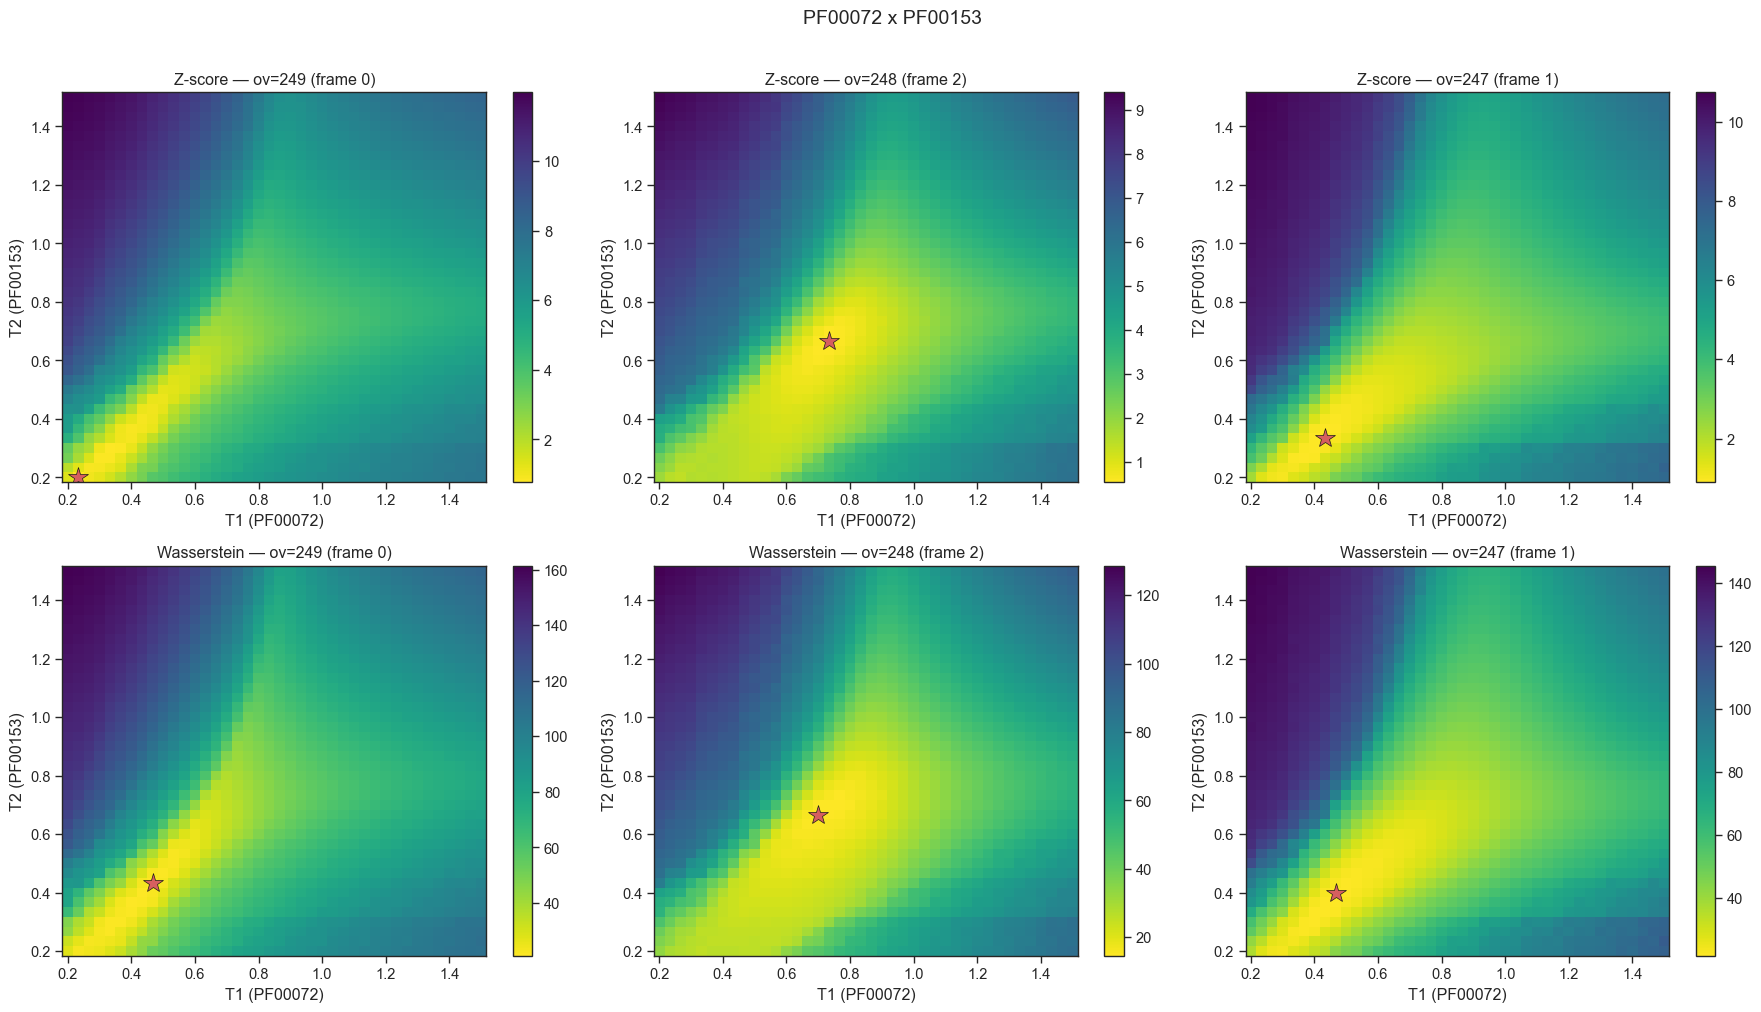

Saved PF00072_PF00153_heatmaps.png


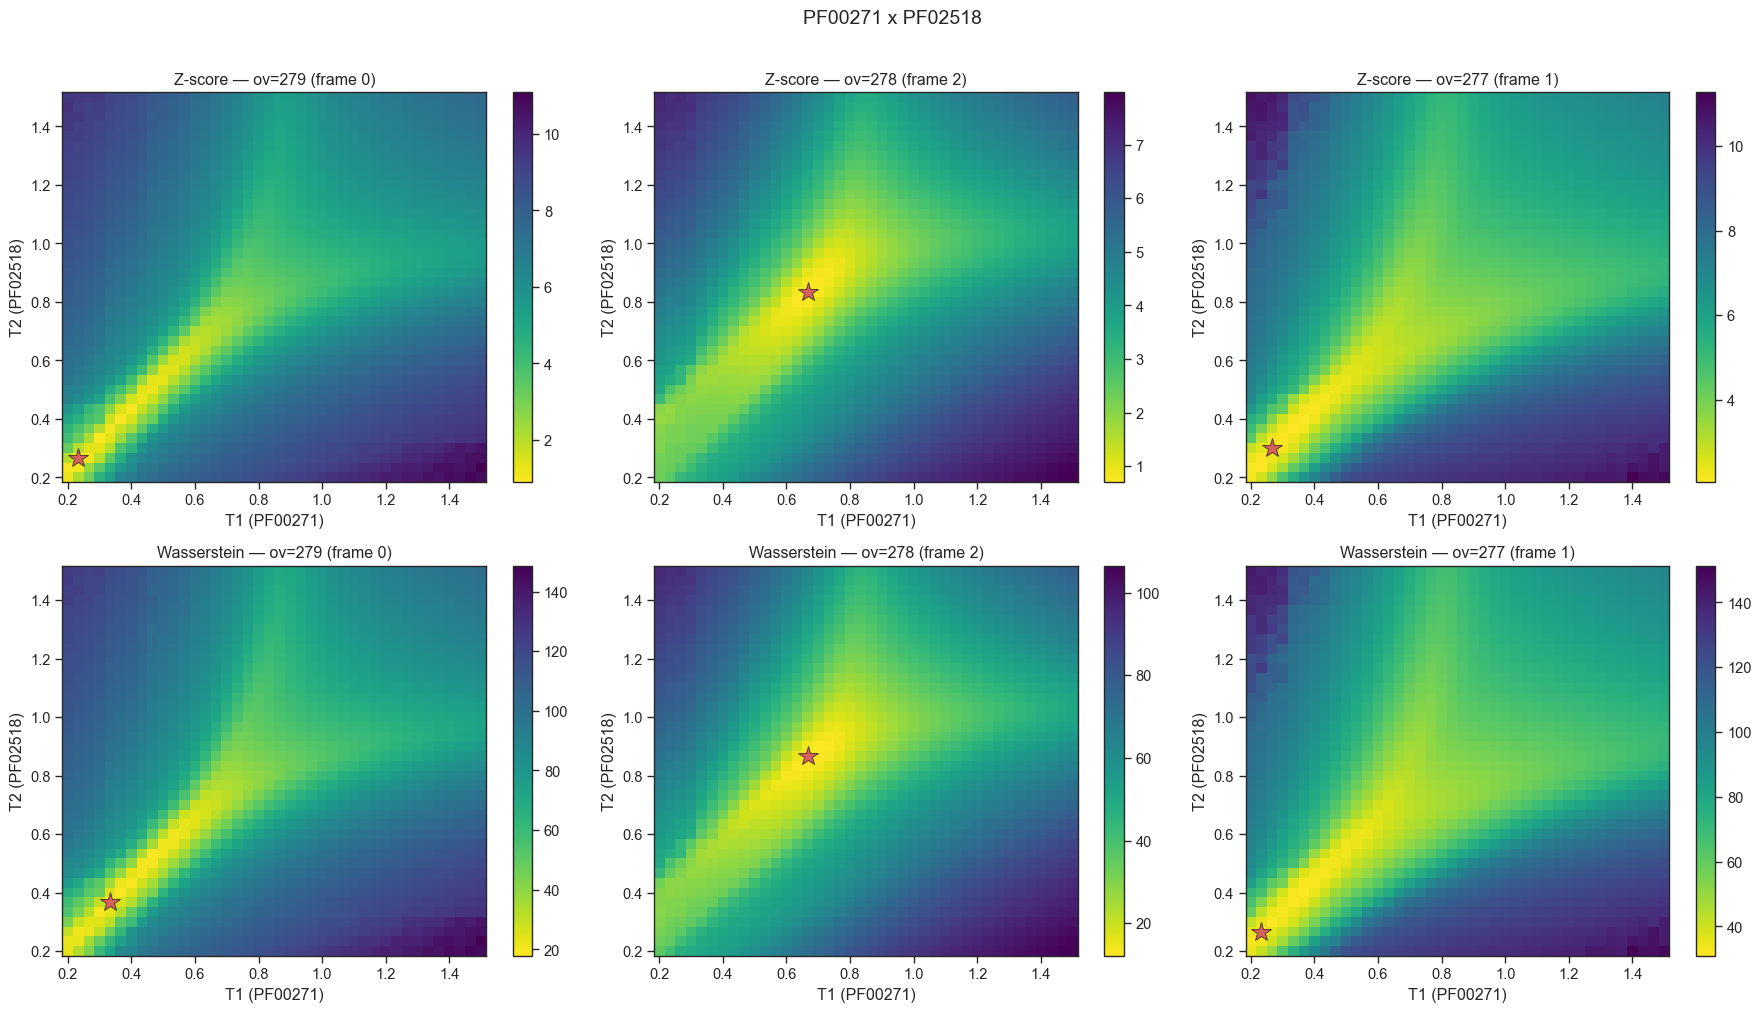

Saved PF00271_PF02518_heatmaps.png


In [4]:
# === Cell 4: Heatmaps — z-score and Wasserstein for each pair/overlap ===

import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

SAVE_DIR = "plots"
os.makedirs(SAVE_DIR, exist_ok=True)

for key, d in results.items():
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    overlaps = d['overlap_lengths']

    fig, axes = plt.subplots(2, len(overlaps), figsize=(6 * len(overlaps), 10))
    if len(overlaps) == 1:
        axes = axes[:, np.newaxis]

    for col, ov in enumerate(overlaps):
        ov = int(ov)
        T1 = d[f'T1_fine_{ov}']
        T2 = d[f'T2_fine_{ov}']
        z_mean = d[f'z_mean_{ov}']
        wass_mean = d[f'wass_mean_{ov}']

        z_min_idx = np.unravel_index(np.argmin(z_mean), z_mean.shape)
        w_min_idx = np.unravel_index(np.argmin(wass_mean), wass_mean.shape)

        # Z-score heatmap
        ax = axes[0, col]
        pcm = ax.pcolormesh(T1, T2, z_mean, cmap='viridis_r', shading='auto')
        ax.plot(T1[z_min_idx[1]], T2[z_min_idx[0]], 'r*', ms=15,
                markeredgecolor='k', markeredgewidth=0.5)
        ax.set_xlabel(f'T1 ({pf1})')
        ax.set_ylabel(f'T2 ({pf2})')
        ax.set_title(f'Z-score — ov={ov} (frame {ov%3})')
        fig.colorbar(pcm, ax=ax)

        # Wasserstein heatmap
        ax = axes[1, col]
        pcm = ax.pcolormesh(T1, T2, wass_mean, cmap='viridis_r', shading='auto')
        ax.plot(T1[w_min_idx[1]], T2[w_min_idx[0]], 'r*', ms=15,
                markeredgecolor='k', markeredgewidth=0.5)
        ax.set_xlabel(f'T1 ({pf1})')
        ax.set_ylabel(f'T2 ({pf2})')
        ax.set_title(f'Wasserstein — ov={ov} (frame {ov%3})')
        fig.colorbar(pcm, ax=ax)

    fig.suptitle(f'{pf1} x {pf2}', fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, f'{key}_heatmaps.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {key}_heatmaps.png")

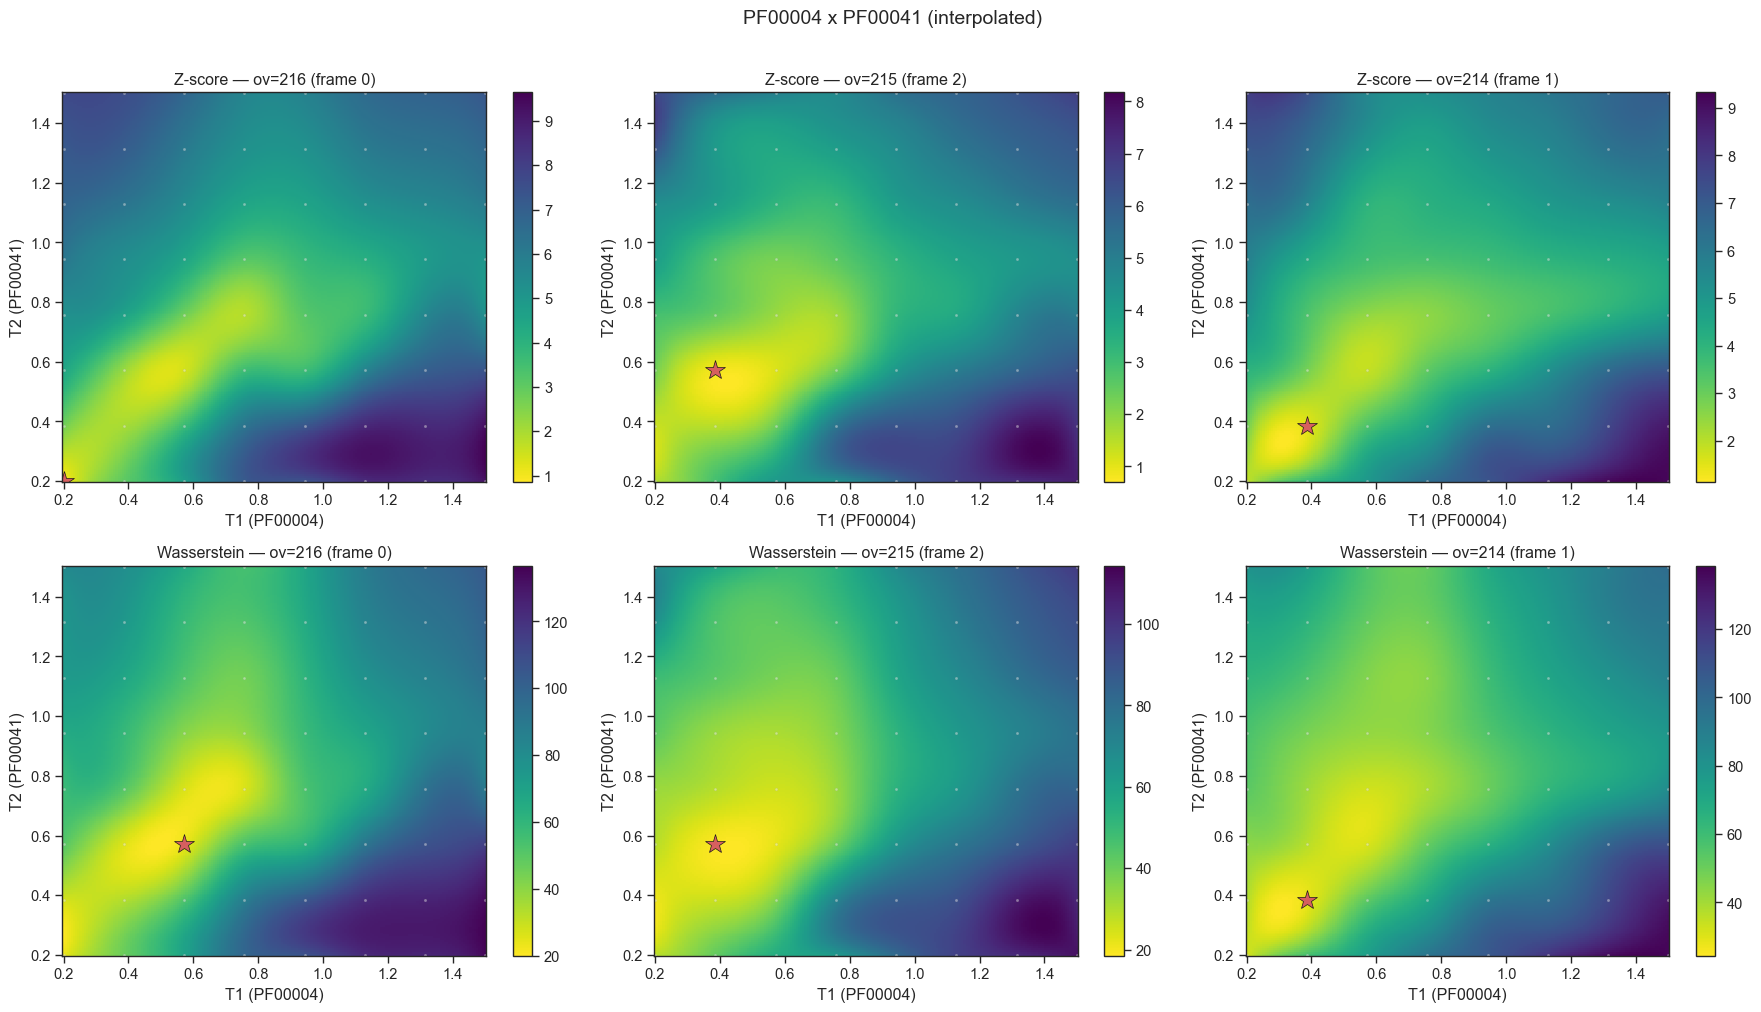

Saved PF00004_PF00041_heatmaps_interp.png


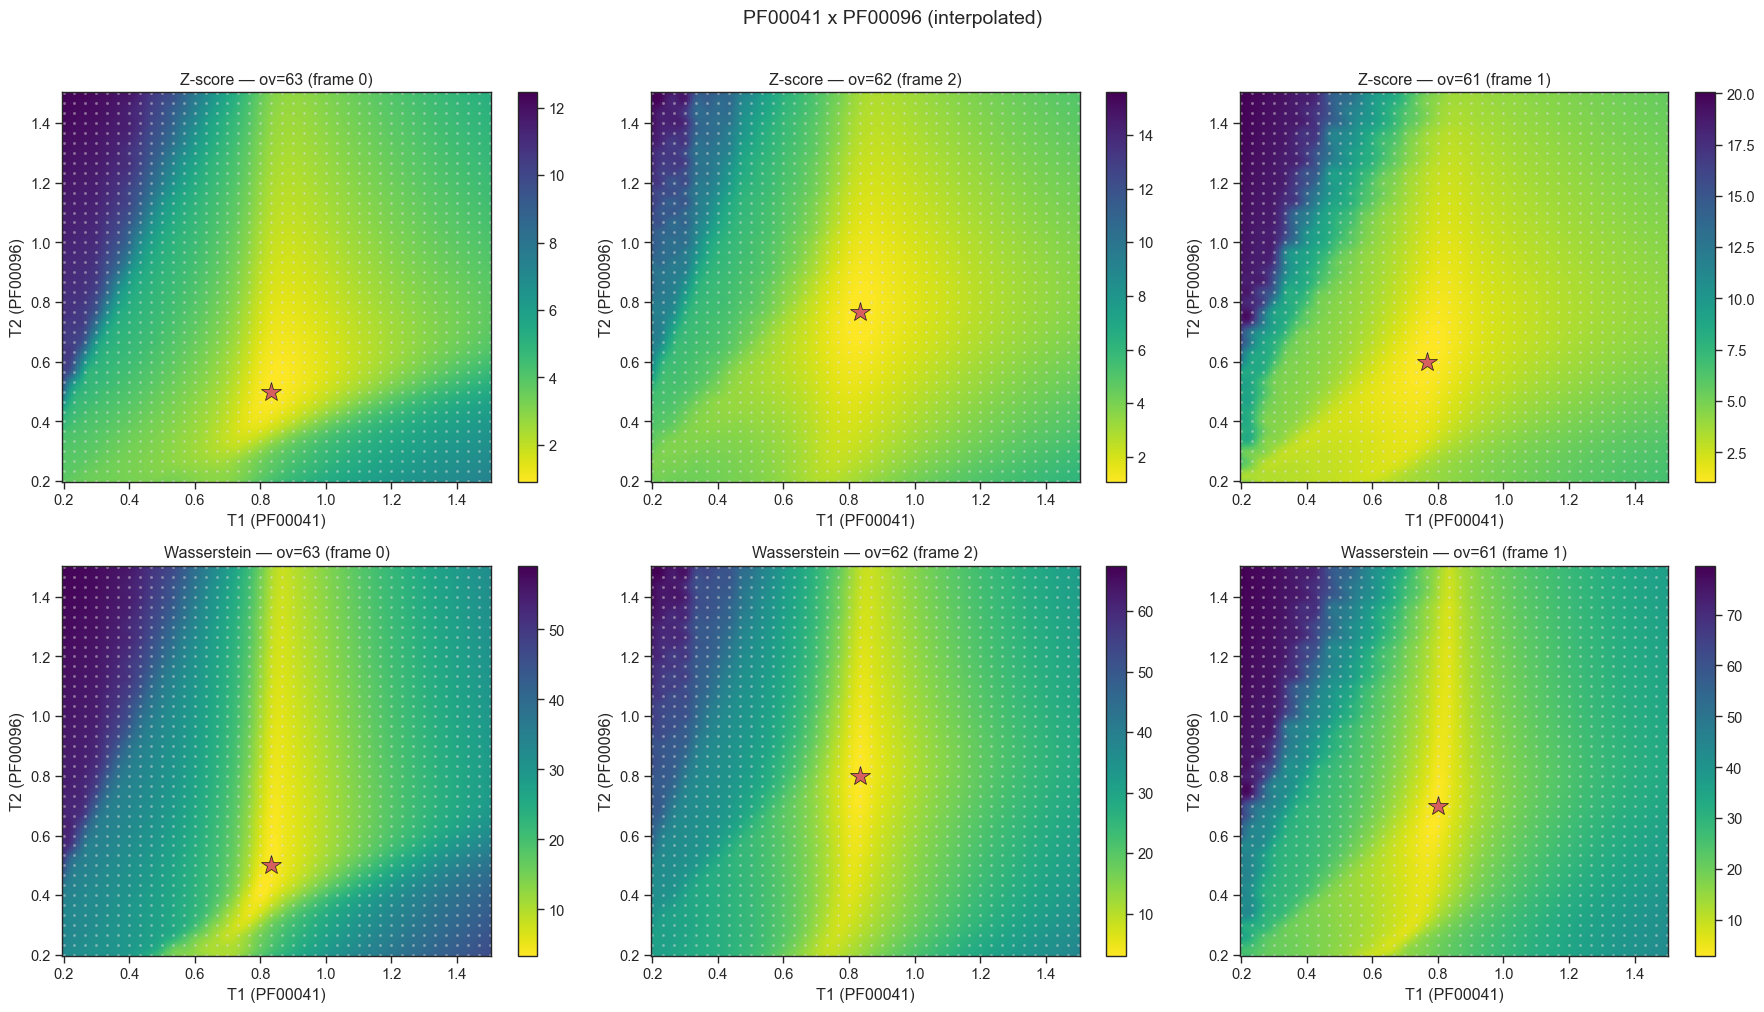

Saved PF00041_PF00096_heatmaps_interp.png


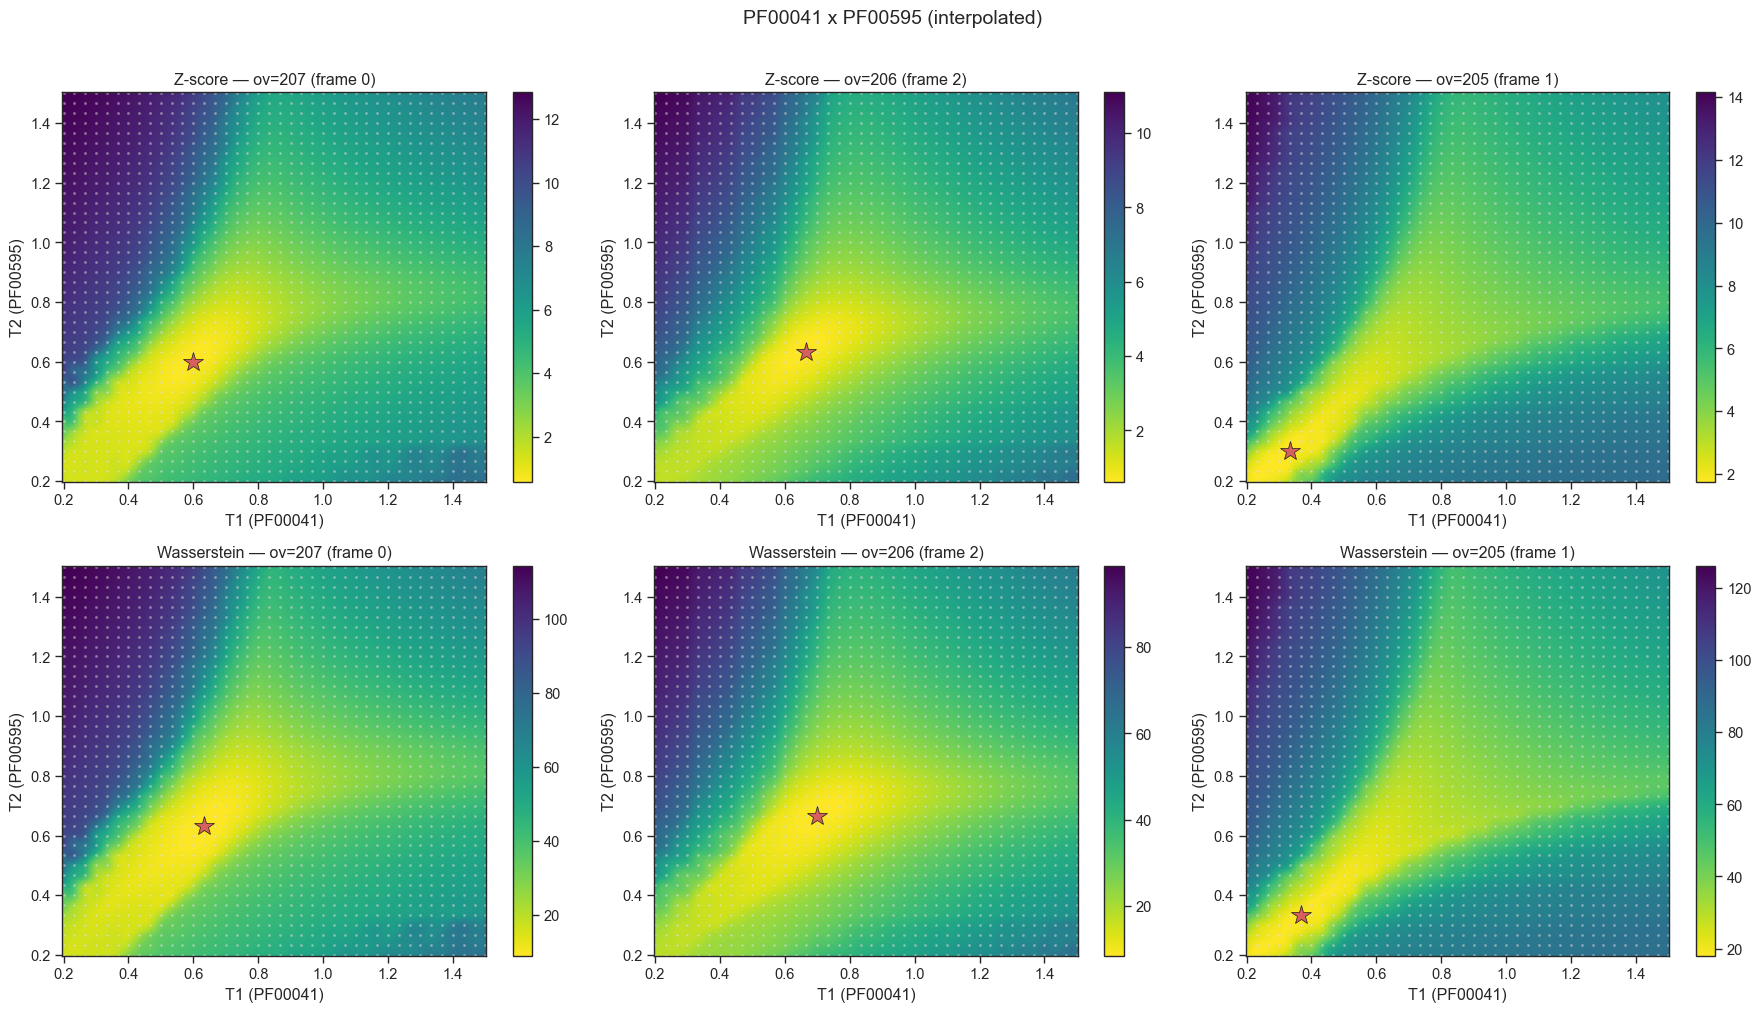

Saved PF00041_PF00595_heatmaps_interp.png


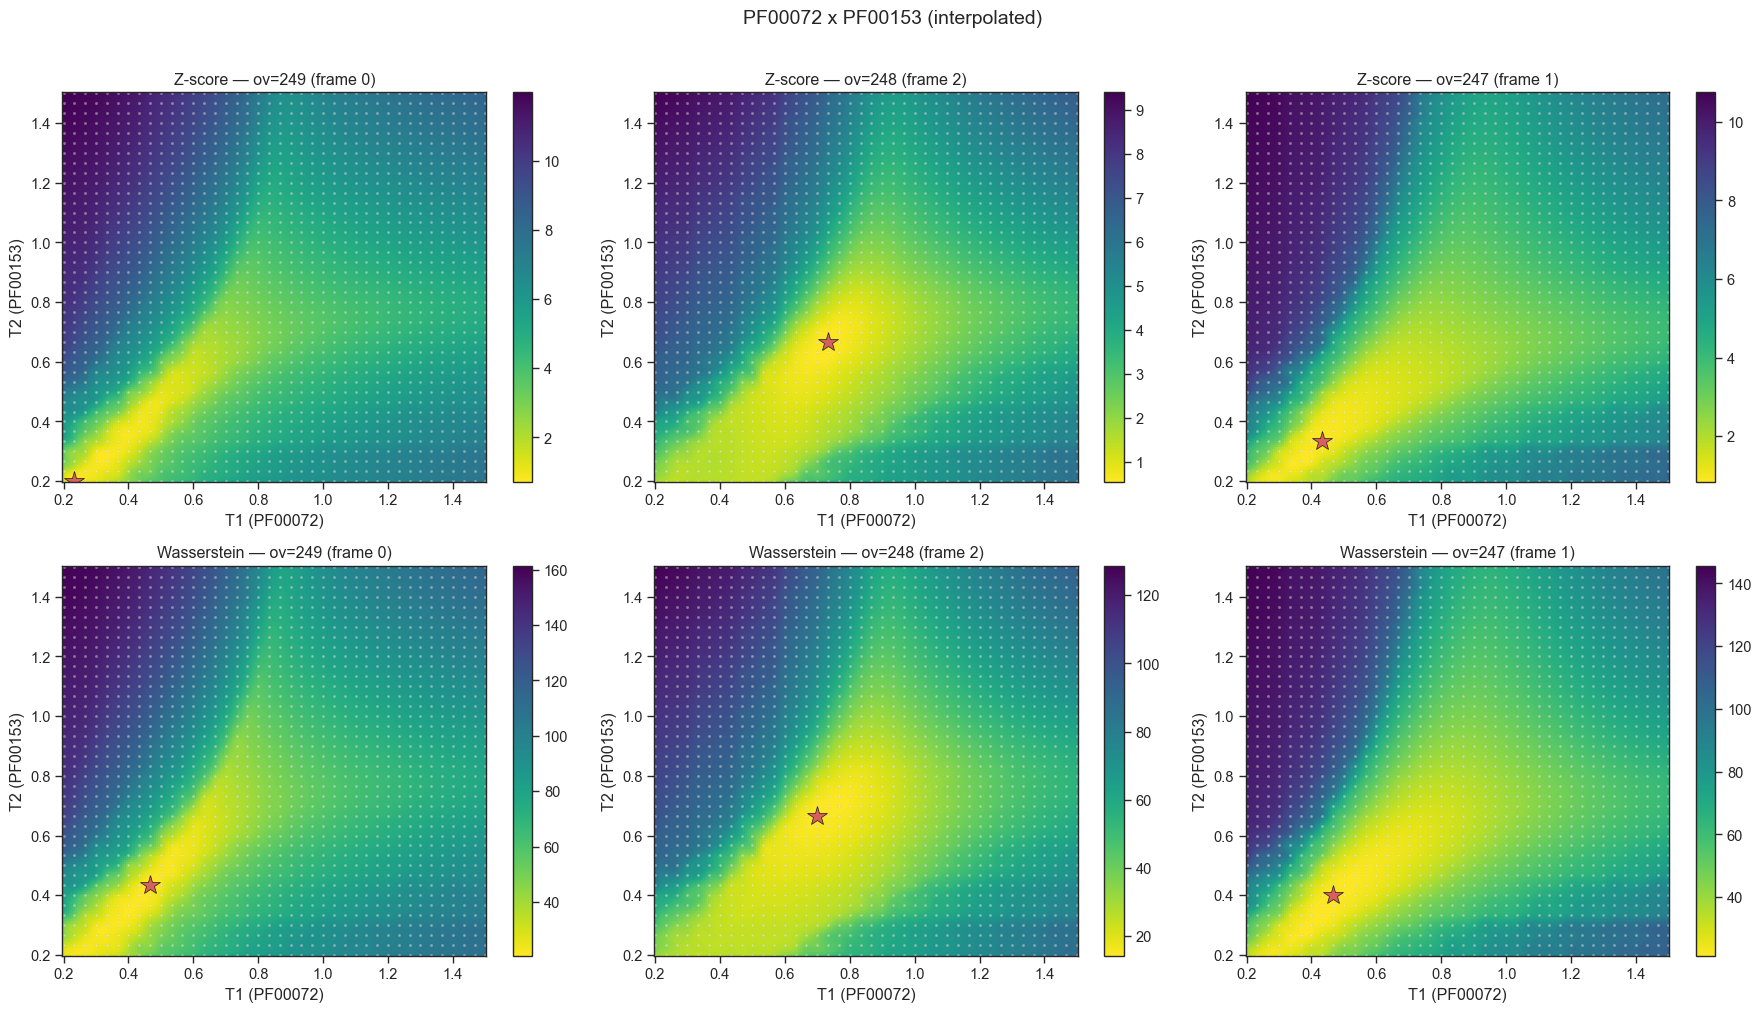

Saved PF00072_PF00153_heatmaps_interp.png


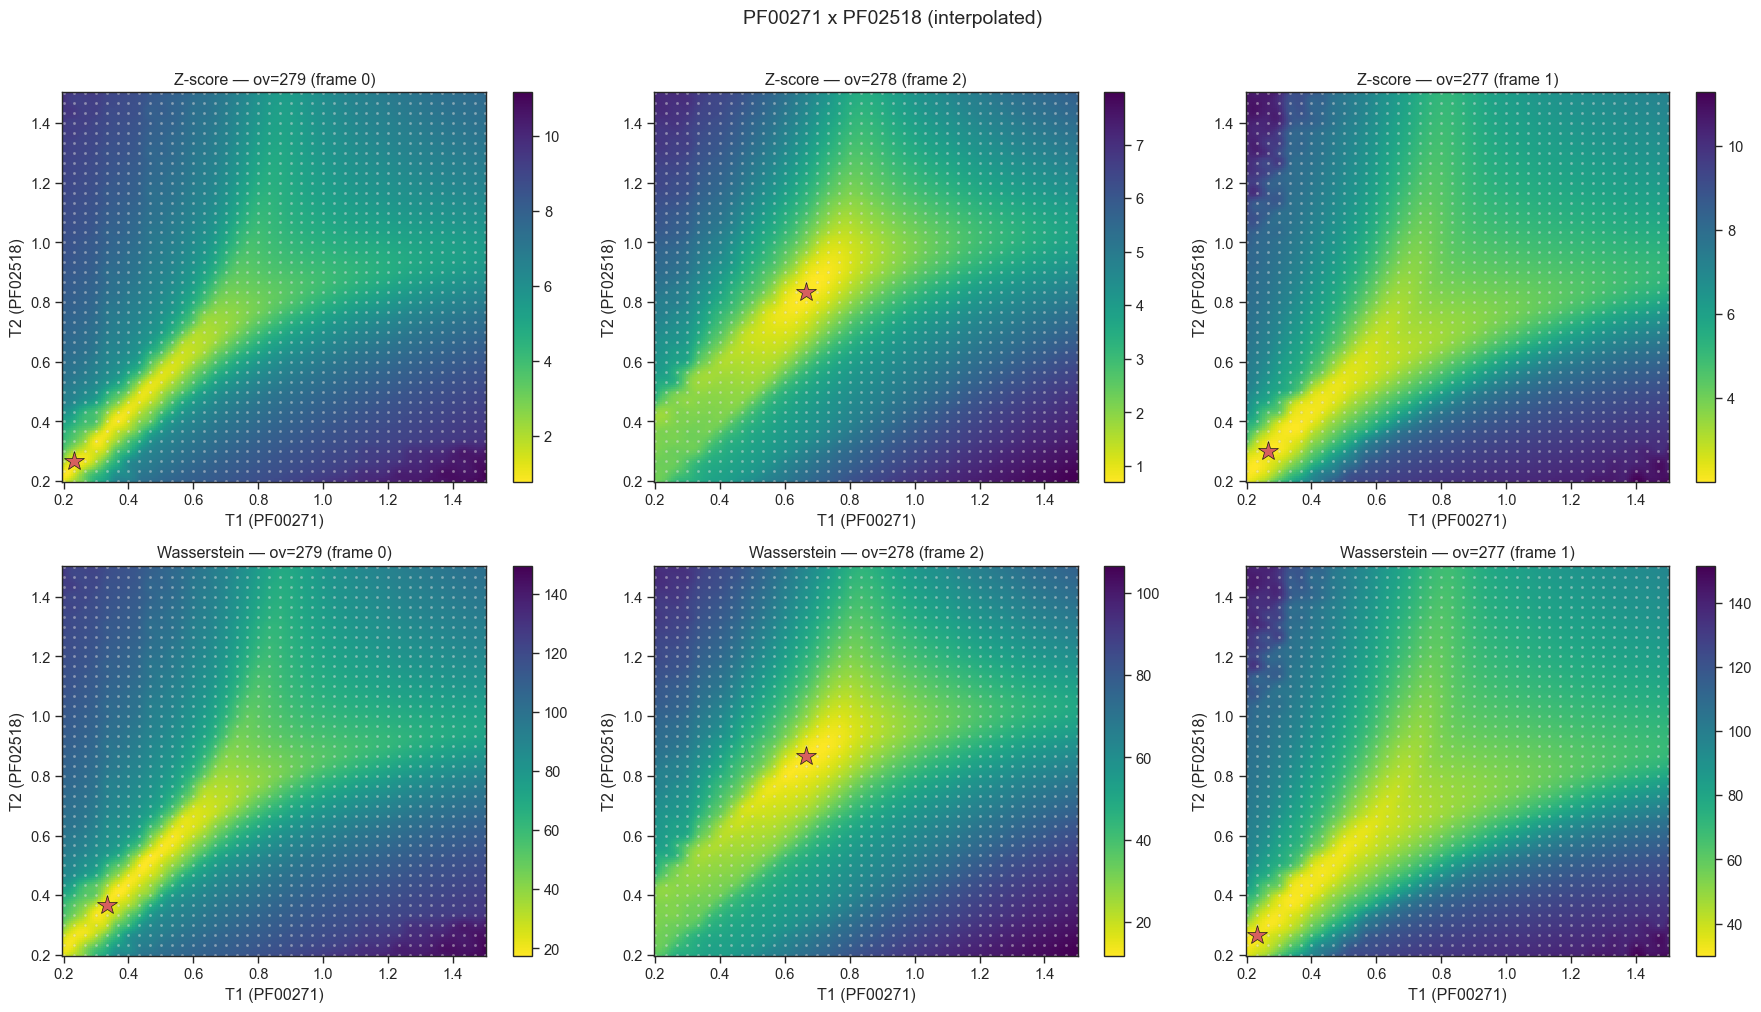

Saved PF00271_PF02518_heatmaps_interp.png


In [5]:
# === Cell 5: Interpolated heatmaps ===

for key, d in results.items():
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    overlaps = d['overlap_lengths']

    fig, axes = plt.subplots(2, len(overlaps), figsize=(6 * len(overlaps), 10))
    if len(overlaps) == 1:
        axes = axes[:, np.newaxis]

    for col, ov in enumerate(overlaps):
        ov = int(ov)
        T1 = d[f'T1_fine_{ov}']
        T2 = d[f'T2_fine_{ov}']
        z_mean = d[f'z_mean_{ov}']
        wass_mean = d[f'wass_mean_{ov}']

        z_min_idx = np.unravel_index(np.argmin(z_mean), z_mean.shape)
        w_min_idx = np.unravel_index(np.argmin(wass_mean), wass_mean.shape)

        T1_smooth = np.linspace(T1.min(), T1.max(), 200)
        T2_smooth = np.linspace(T2.min(), T2.max(), 200)
        T1_mesh, T2_mesh = np.meshgrid(T1_smooth, T2_smooth)
        query_pts = np.column_stack([T2_mesh.ravel(), T1_mesh.ravel()])

        for row, (grid, title, best_idx) in enumerate([
            (z_mean, 'Z-score', z_min_idx),
            (wass_mean, 'Wasserstein', w_min_idx),
        ]):
            ax = axes[row, col]
            interp = RegularGridInterpolator(
                (T2, T1), grid, method='cubic', bounds_error=False)
            grid_smooth = interp(query_pts).reshape(T2_mesh.shape)

            pcm = ax.pcolormesh(T1_smooth, T2_smooth, grid_smooth,
                                cmap='viridis_r', shading='auto')
            T1_pts, T2_pts = np.meshgrid(T1, T2)
            ax.scatter(T1_pts.ravel(), T2_pts.ravel(), c='white', s=4,
                       alpha=0.4, edgecolors='gray', linewidths=0.2)
            ax.plot(T1[best_idx[1]], T2[best_idx[0]], 'r*', ms=15,
                    markeredgecolor='k', markeredgewidth=0.5)
            ax.set_xlabel(f'T1 ({pf1})')
            ax.set_ylabel(f'T2 ({pf2})')
            ax.set_title(f'{title} — ov={ov} (frame {ov%3})')
            fig.colorbar(pcm, ax=ax)

    fig.suptitle(f'{pf1} x {pf2} (interpolated)', fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, f'{key}_heatmaps_interp.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {key}_heatmaps_interp.png")

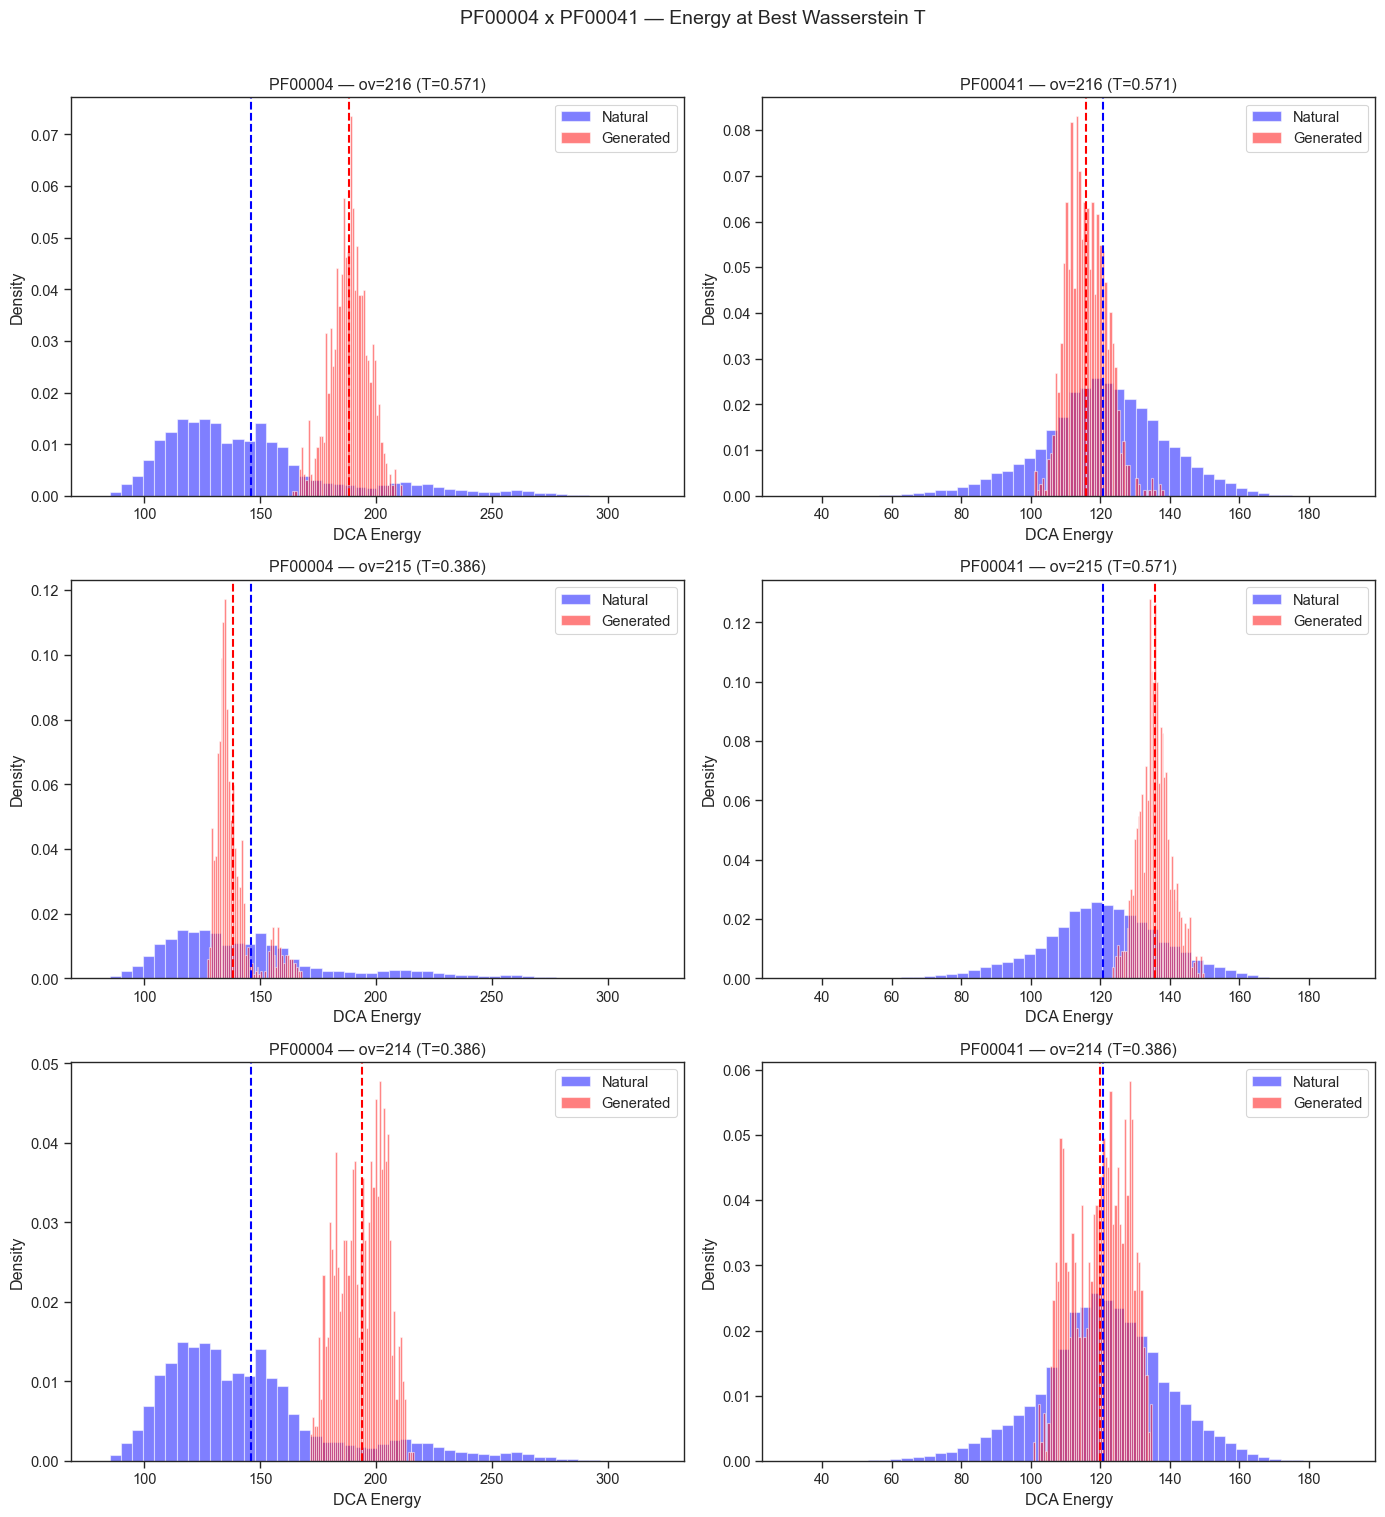

Saved PF00004_PF00041_energy_hist.png


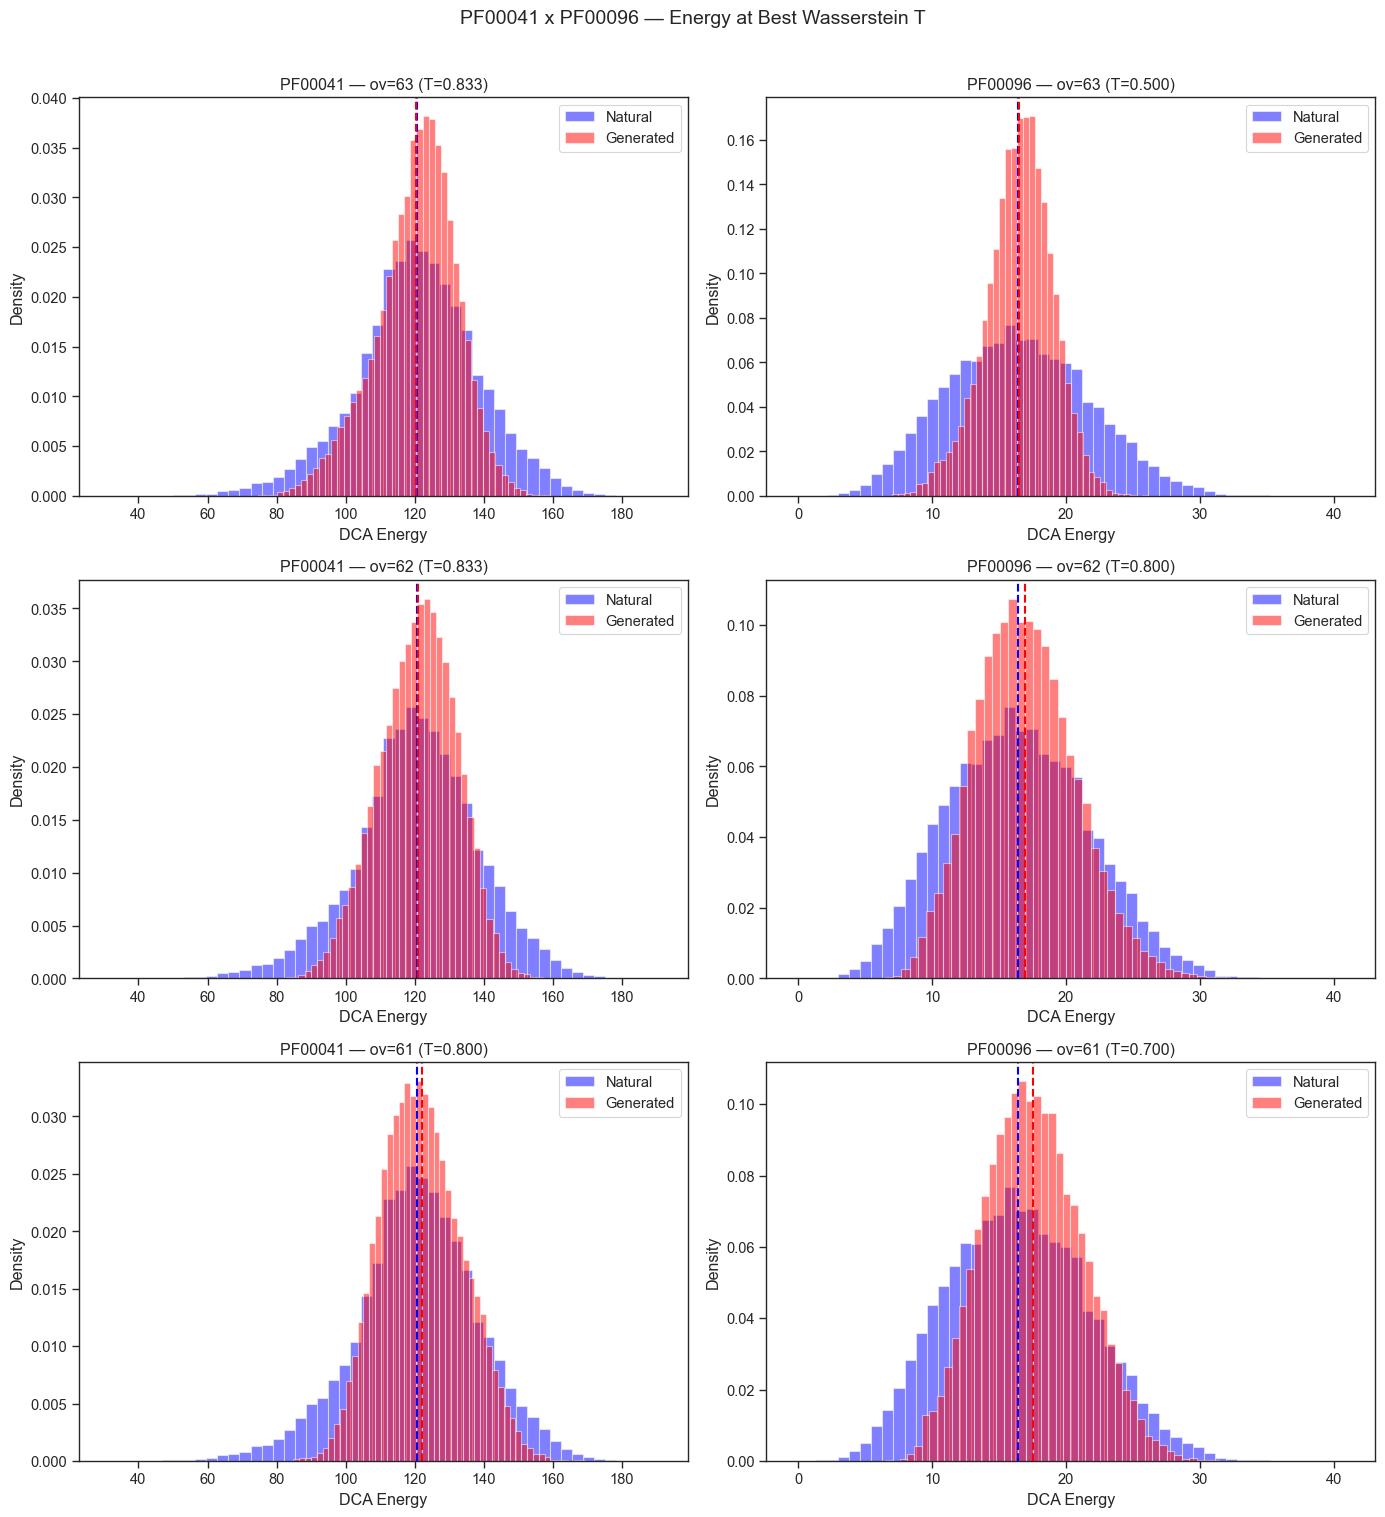

Saved PF00041_PF00096_energy_hist.png


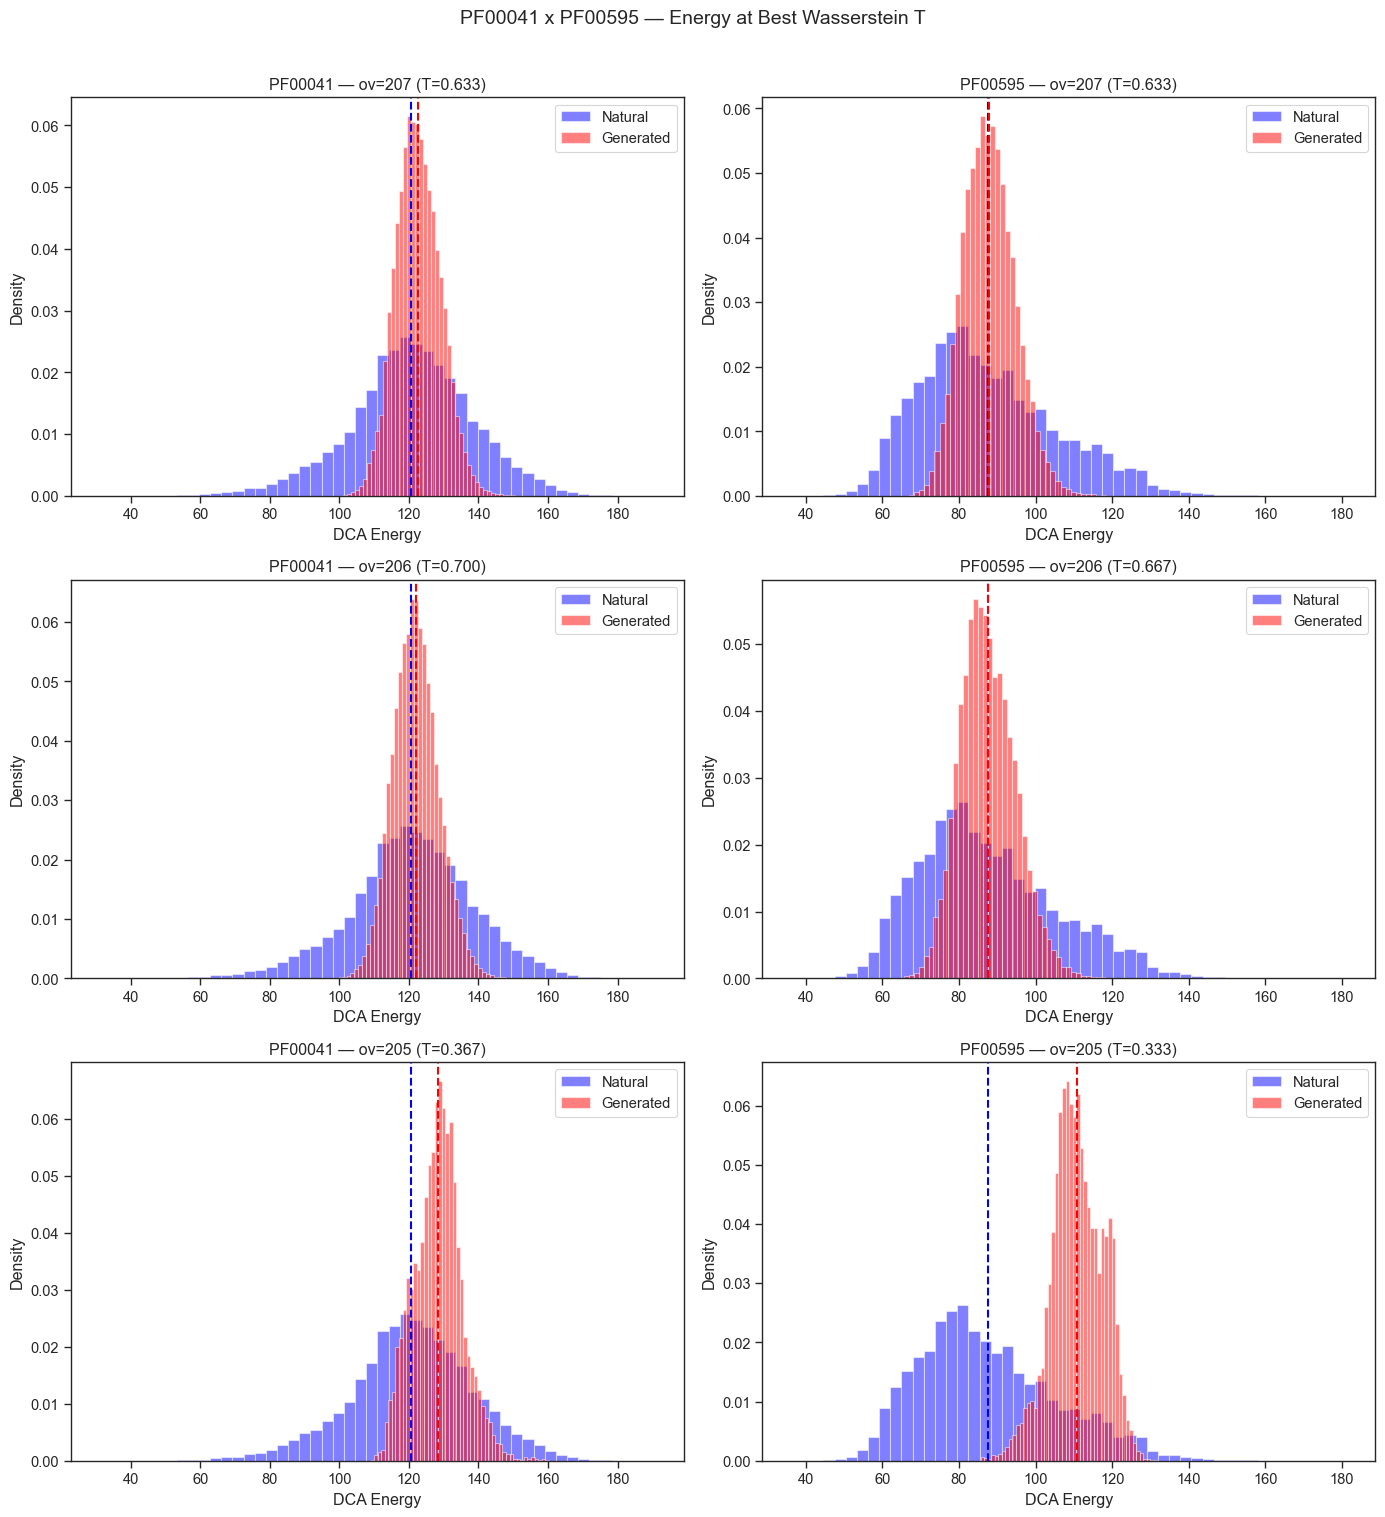

Saved PF00041_PF00595_energy_hist.png


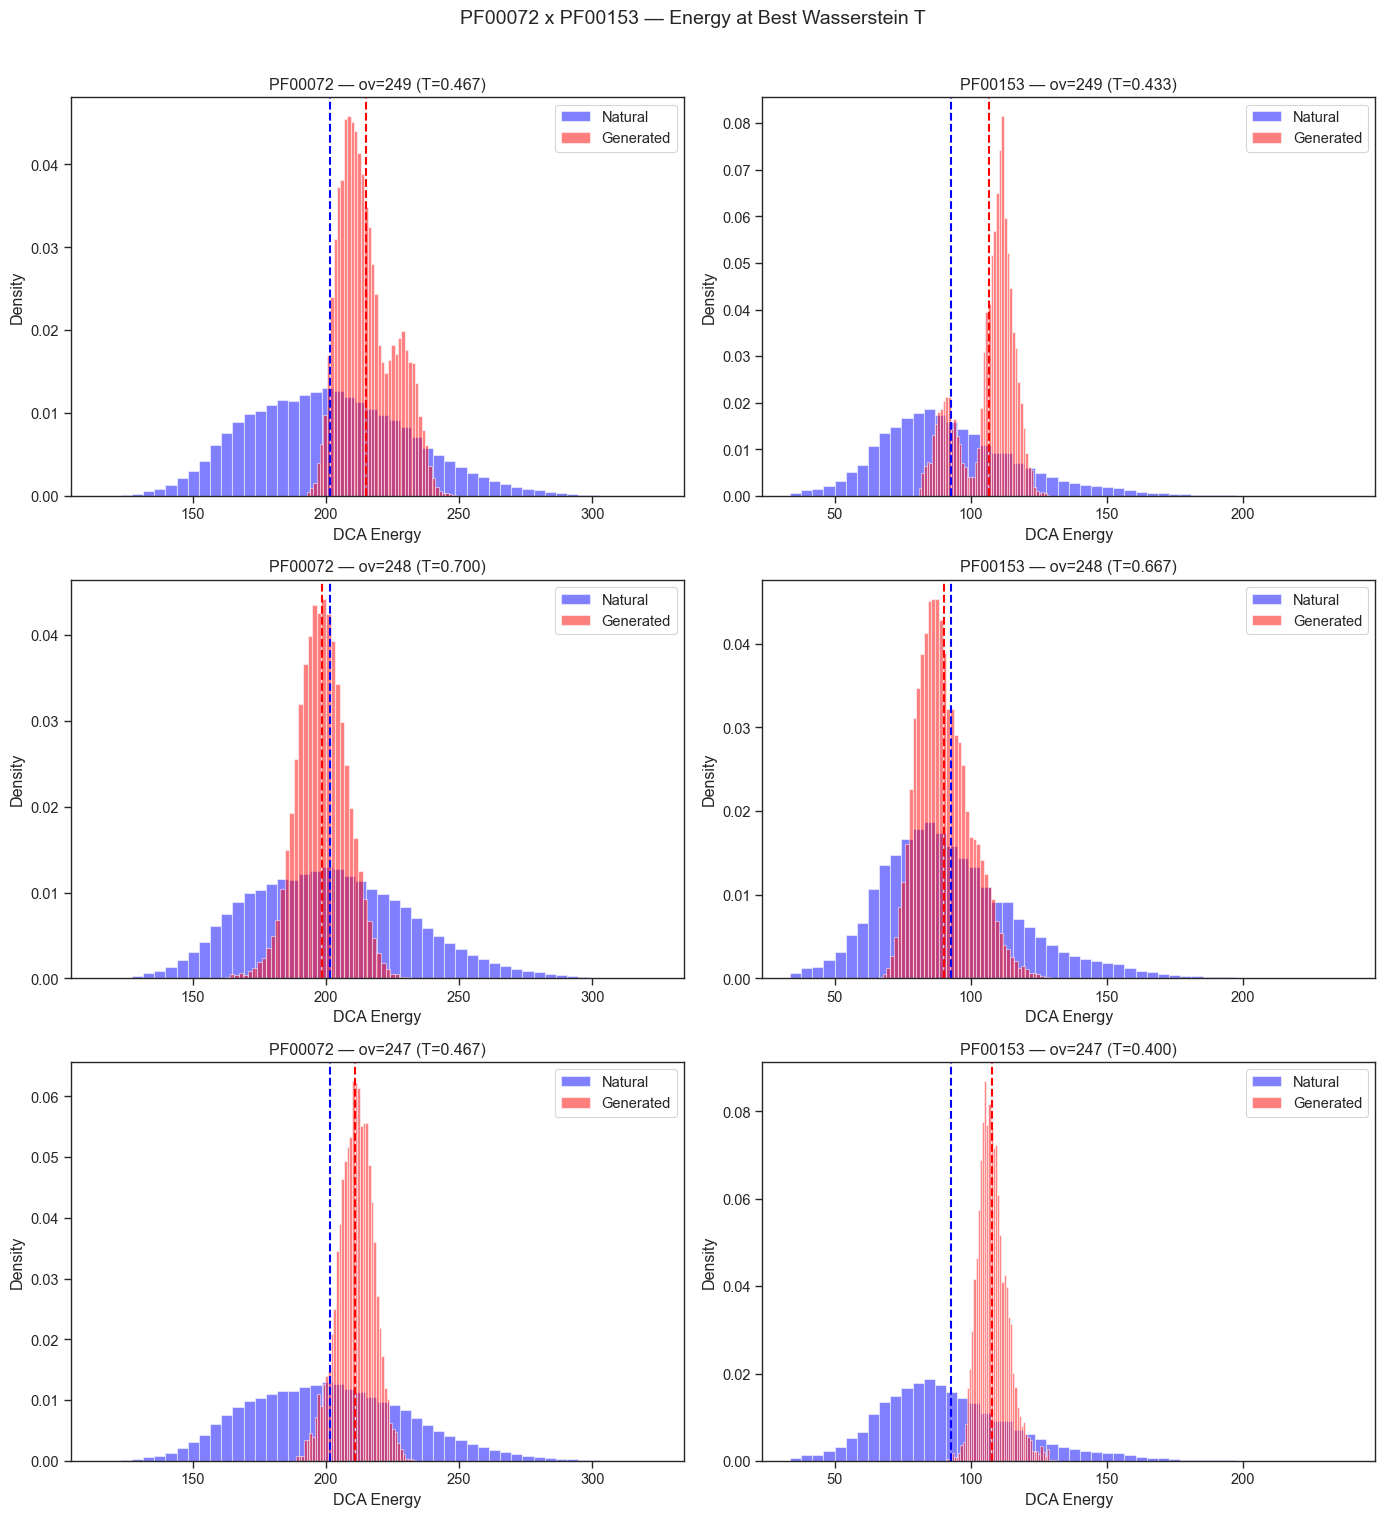

Saved PF00072_PF00153_energy_hist.png


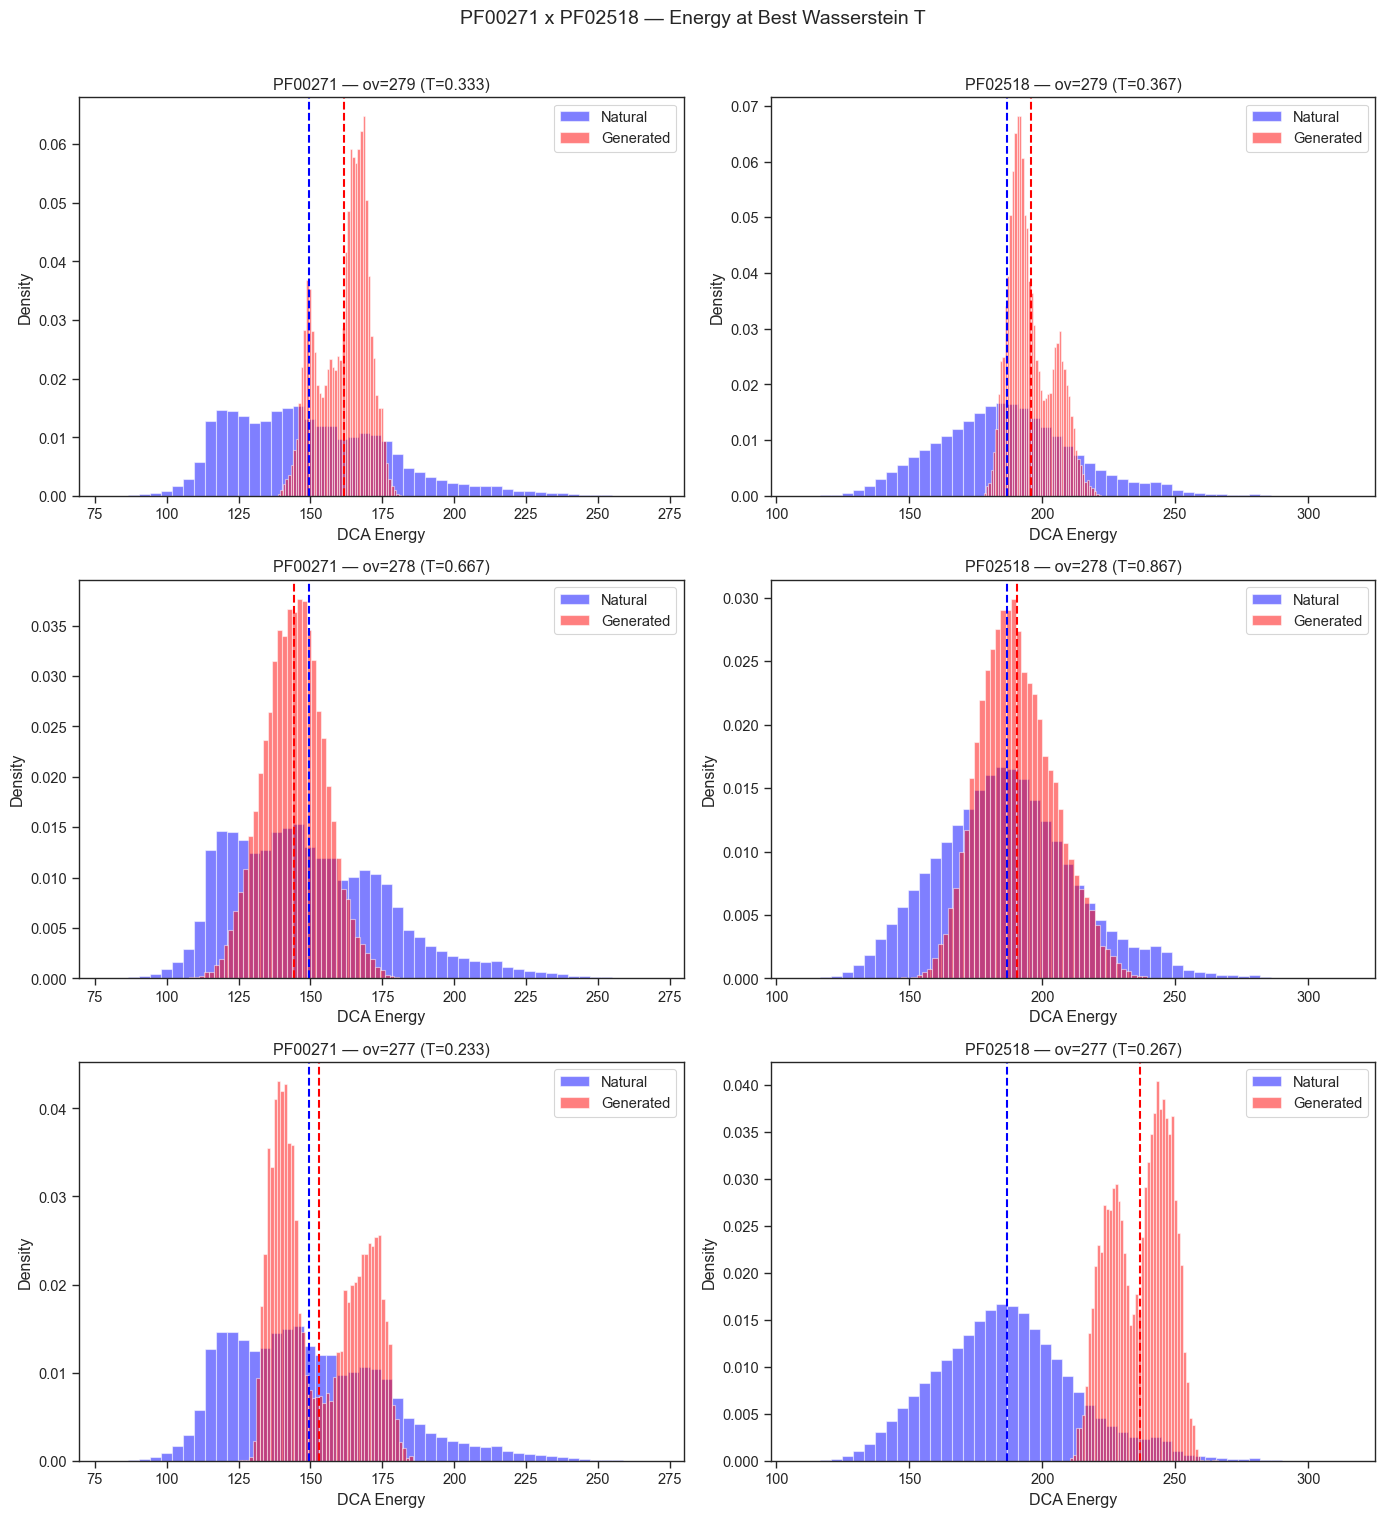

Saved PF00271_PF02518_energy_hist.png


In [6]:
# === Cell 6: Energy histograms at best temperatures ===

for key, d in results.items():
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    nat_mean1, nat_std1 = float(d['nat_mean_1']), float(d['nat_std_1'])
    nat_mean2, nat_std2 = float(d['nat_mean_2']), float(d['nat_std_2'])
    overlaps = d['overlap_lengths']

    fig, axes = plt.subplots(len(overlaps), 2, figsize=(14, 5 * len(overlaps)))
    if len(overlaps) == 1:
        axes = axes[np.newaxis, :]

    for row, ov in enumerate(overlaps):
        ov = int(ov)
        T1 = d[f'T1_fine_{ov}']
        T2 = d[f'T2_fine_{ov}']
        wass_mean = d[f'wass_mean_{ov}']
        w_min_idx = np.unravel_index(np.argmin(wass_mean), wass_mean.shape)

        # Use Wasserstein-best energy samples
        E1_best = d[f'wass_best_E1_{ov}'][0]  # best point, first entry
        E2_best = d[f'wass_best_E2_{ov}'][0]

        for col, (E_gen, pf, nat_e, T_val) in enumerate([
            (E1_best, pf1, nat_energies.get(pf1), T1[w_min_idx[1]]),
            (E2_best, pf2, nat_energies.get(pf2), T2[w_min_idx[0]]),
        ]):
            ax = axes[row, col]
            if nat_e is not None:
                ax.hist(nat_e, bins=50, density=True, alpha=0.5,
                        color='blue', label='Natural')
            ax.hist(E_gen, bins=50, density=True, alpha=0.5,
                    color='red', label='Generated')
            if nat_e is not None:
                ax.axvline(np.mean(nat_e), color='blue', ls='--', lw=1.5)
            ax.axvline(np.mean(E_gen), color='red', ls='--', lw=1.5)
            ax.set_xlabel('DCA Energy')
            ax.set_ylabel('Density')
            ax.set_title(f'{pf} — ov={ov} (T={T_val:.3f})')
            ax.legend()

    fig.suptitle(f'{pf1} x {pf2} — Energy at Best Wasserstein T',
                 fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, f'{key}_energy_hist.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {key}_energy_hist.png")

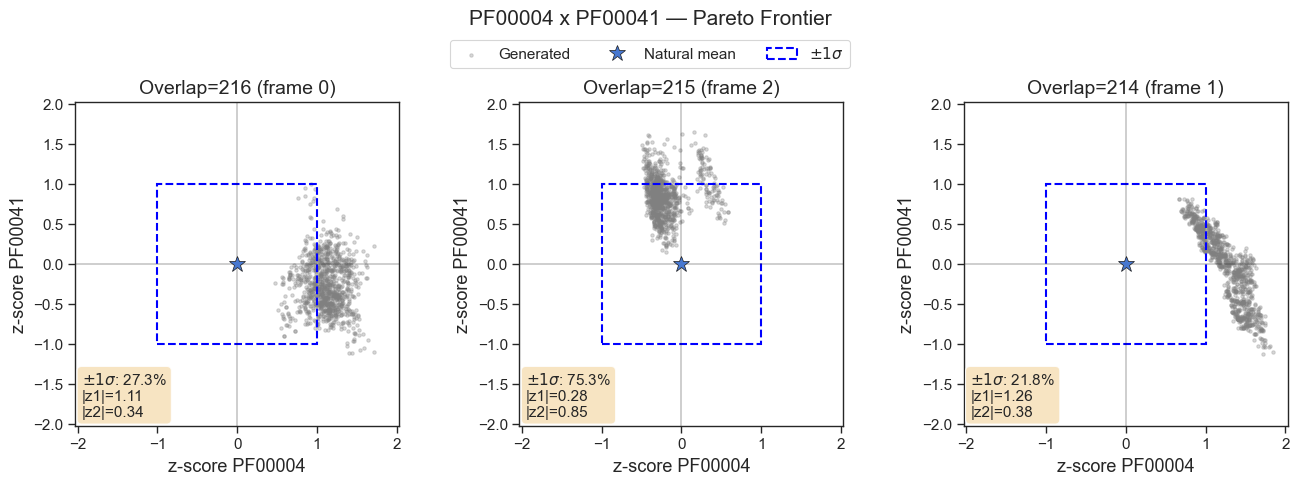

Saved PF00004_PF00041_pareto.png


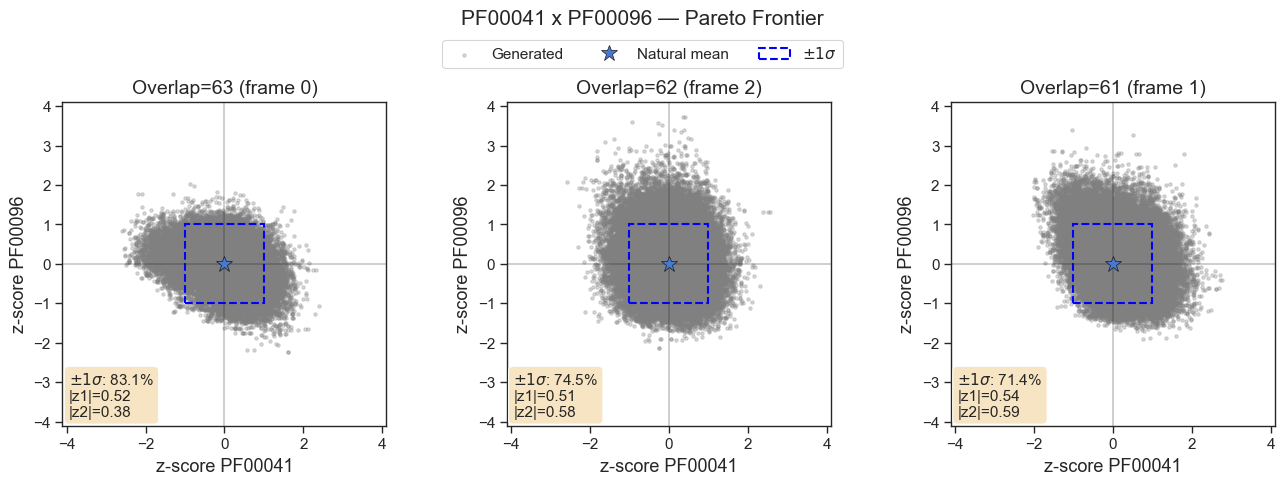

Saved PF00041_PF00096_pareto.png


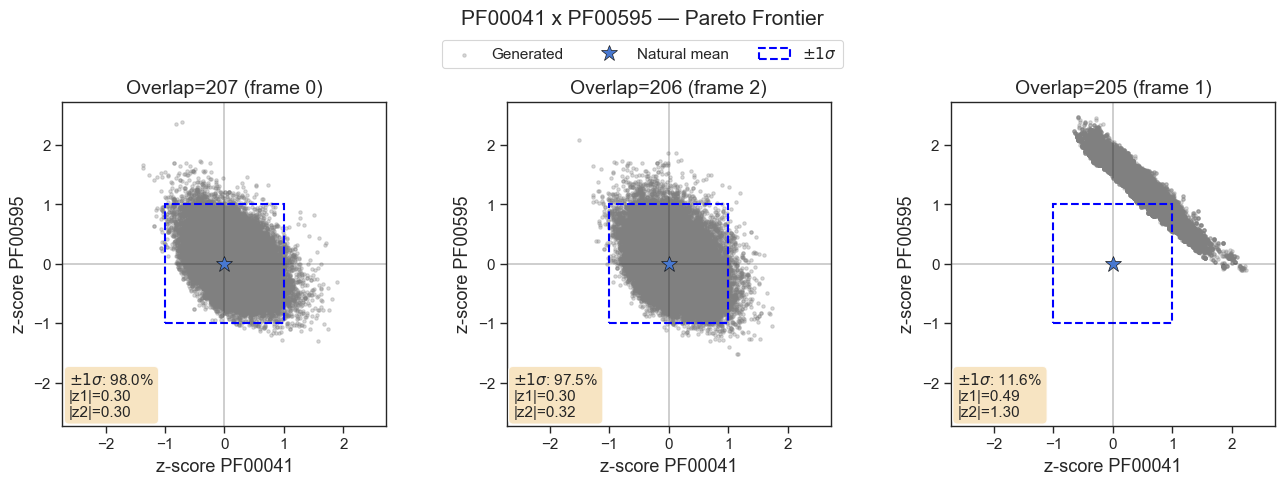

Saved PF00041_PF00595_pareto.png


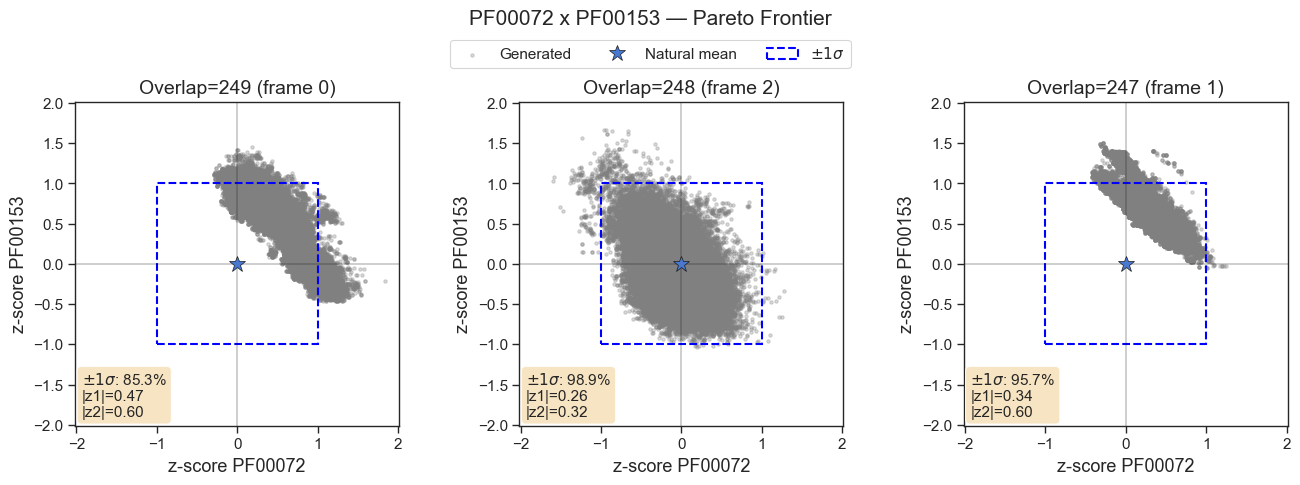

Saved PF00072_PF00153_pareto.png


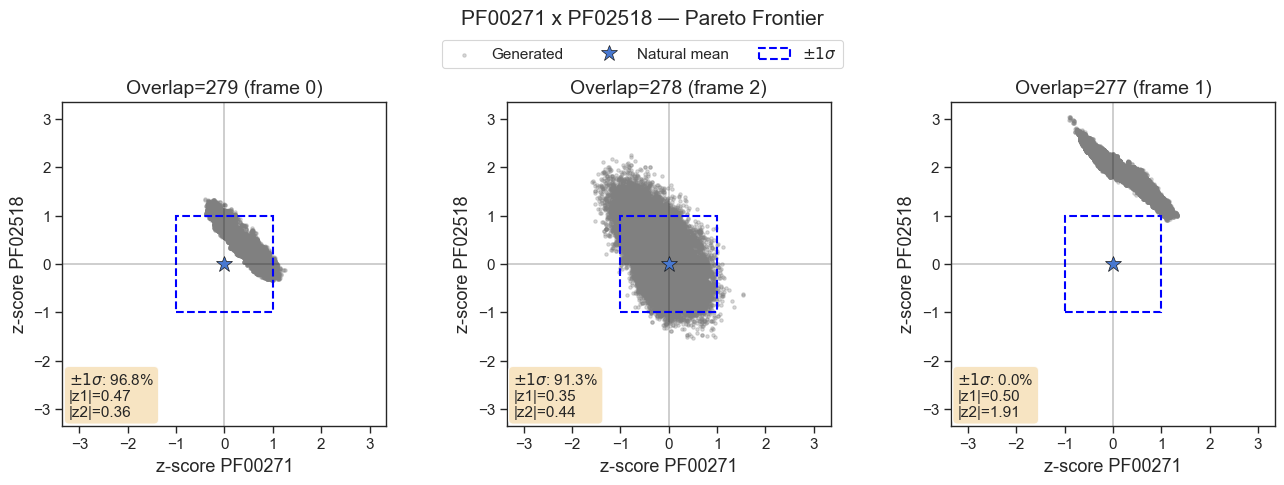

Saved PF00271_PF02518_pareto.png


In [41]:
# === Cell 7: Pareto frontier at best Wasserstein T ===

for key, d in results.items():
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    nat_mean1, nat_std1 = float(d['nat_mean_1']), float(d['nat_std_1'])
    nat_mean2, nat_std2 = float(d['nat_mean_2']), float(d['nat_std_2'])
    overlaps = d['overlap_lengths']

    # Pre-compute shared axis limits across all overlaps
    all_z1, all_z2 = [], []
    for ov in overlaps:
        ov = int(ov)
        E1_best = d[f'wass_best_E1_{ov}'][0]
        E2_best = d[f'wass_best_E2_{ov}'][0]
        all_z1.append((E1_best - nat_mean1) / nat_std1)
        all_z2.append((E2_best - nat_mean2) / nat_std2)
    all_z = np.concatenate(all_z1 + all_z2)
    lim = max(np.abs(all_z.min()), np.abs(all_z.max())) * 1.1

    fig, axes = plt.subplots(1, len(overlaps), figsize=(4.5 * len(overlaps), 4.5))
    if len(overlaps) == 1:
        axes = [axes]

    for col, ov in enumerate(overlaps):
        ov = int(ov)
        ax = axes[col]

        # Best Wasserstein energies
        E1_best = d[f'wass_best_E1_{ov}'][0]
        E2_best = d[f'wass_best_E2_{ov}'][0]

        z1 = (E1_best - nat_mean1) / nat_std1
        z2 = (E2_best - nat_mean2) / nat_std2

        ax.scatter(z1, z2, s=6, alpha=0.3, c='gray', label='Generated')
        ax.plot(0, 0, 'b*', ms=12, markeredgecolor='k',
                markeredgewidth=0.5, zorder=5, label='Natural mean')

        rect = plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor='blue',
                              ls='--', lw=1.5, label=r'$\pm 1\sigma$')
        ax.add_patch(rect)

        ax.set_xlabel(f'z-score {pf1}', fontsize=13)
        ax.set_ylabel(f'z-score {pf2}', fontsize=13)
        ax.set_title(f'Overlap={ov} (frame {ov%3})', fontsize=14)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=11)
        ax.axhline(0, color='k', lw=0.3)
        ax.axvline(0, color='k', lw=0.3)

        within = np.sum((np.abs(z1) <= 1) & (np.abs(z2) <= 1)) / len(z1) * 100
        ax.text(0.02, 0.02, f'$\\pm 1\\sigma$: {within:.1f}%\n'
                f'|z1|={np.mean(np.abs(z1)):.2f}\n'
                f'|z2|={np.mean(np.abs(z2)):.2f}',
                transform=ax.transAxes, fontsize=11, va='bottom',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Single legend below the title, horizontal
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', fontsize=11,
               ncol=3, bbox_to_anchor=(0.5, 0.98))

    fig.suptitle(f'{pf1} x {pf2} — Pareto Frontier', fontsize=15, y=1.03)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(os.path.join(SAVE_DIR, f'{key}_pareto.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {key}_pareto.png")

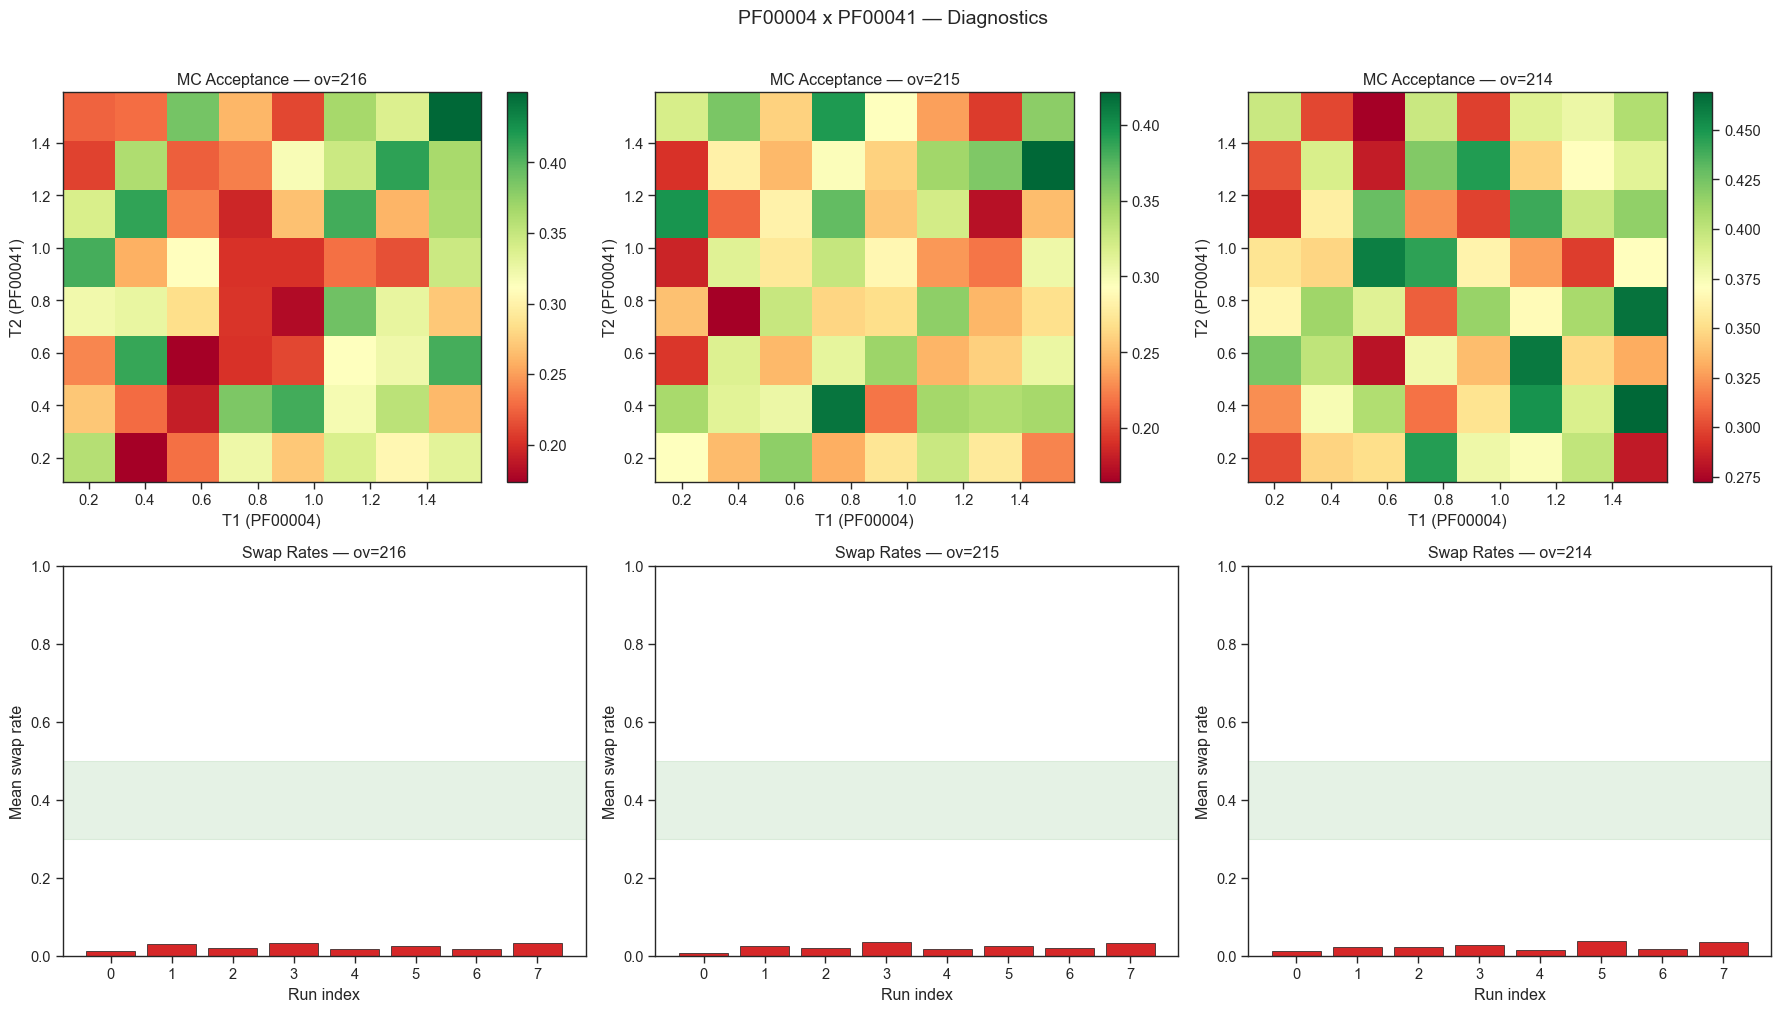

Saved PF00004_PF00041_diagnostics.png


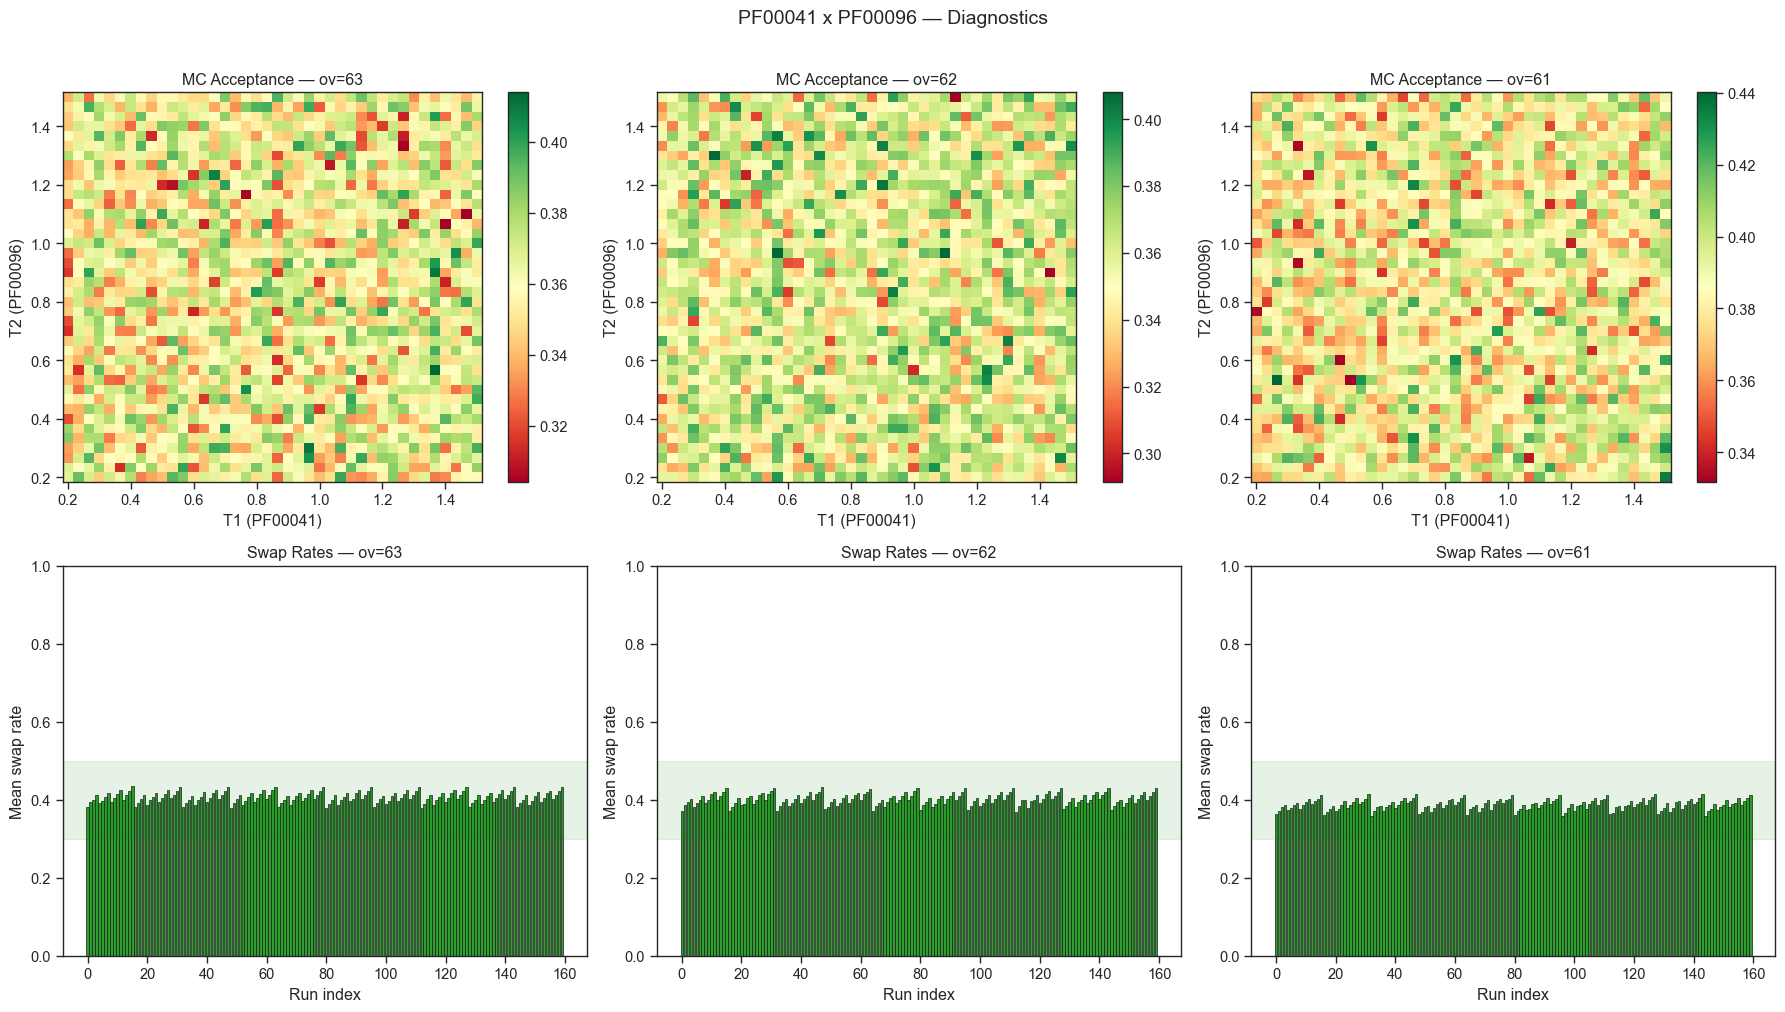

Saved PF00041_PF00096_diagnostics.png


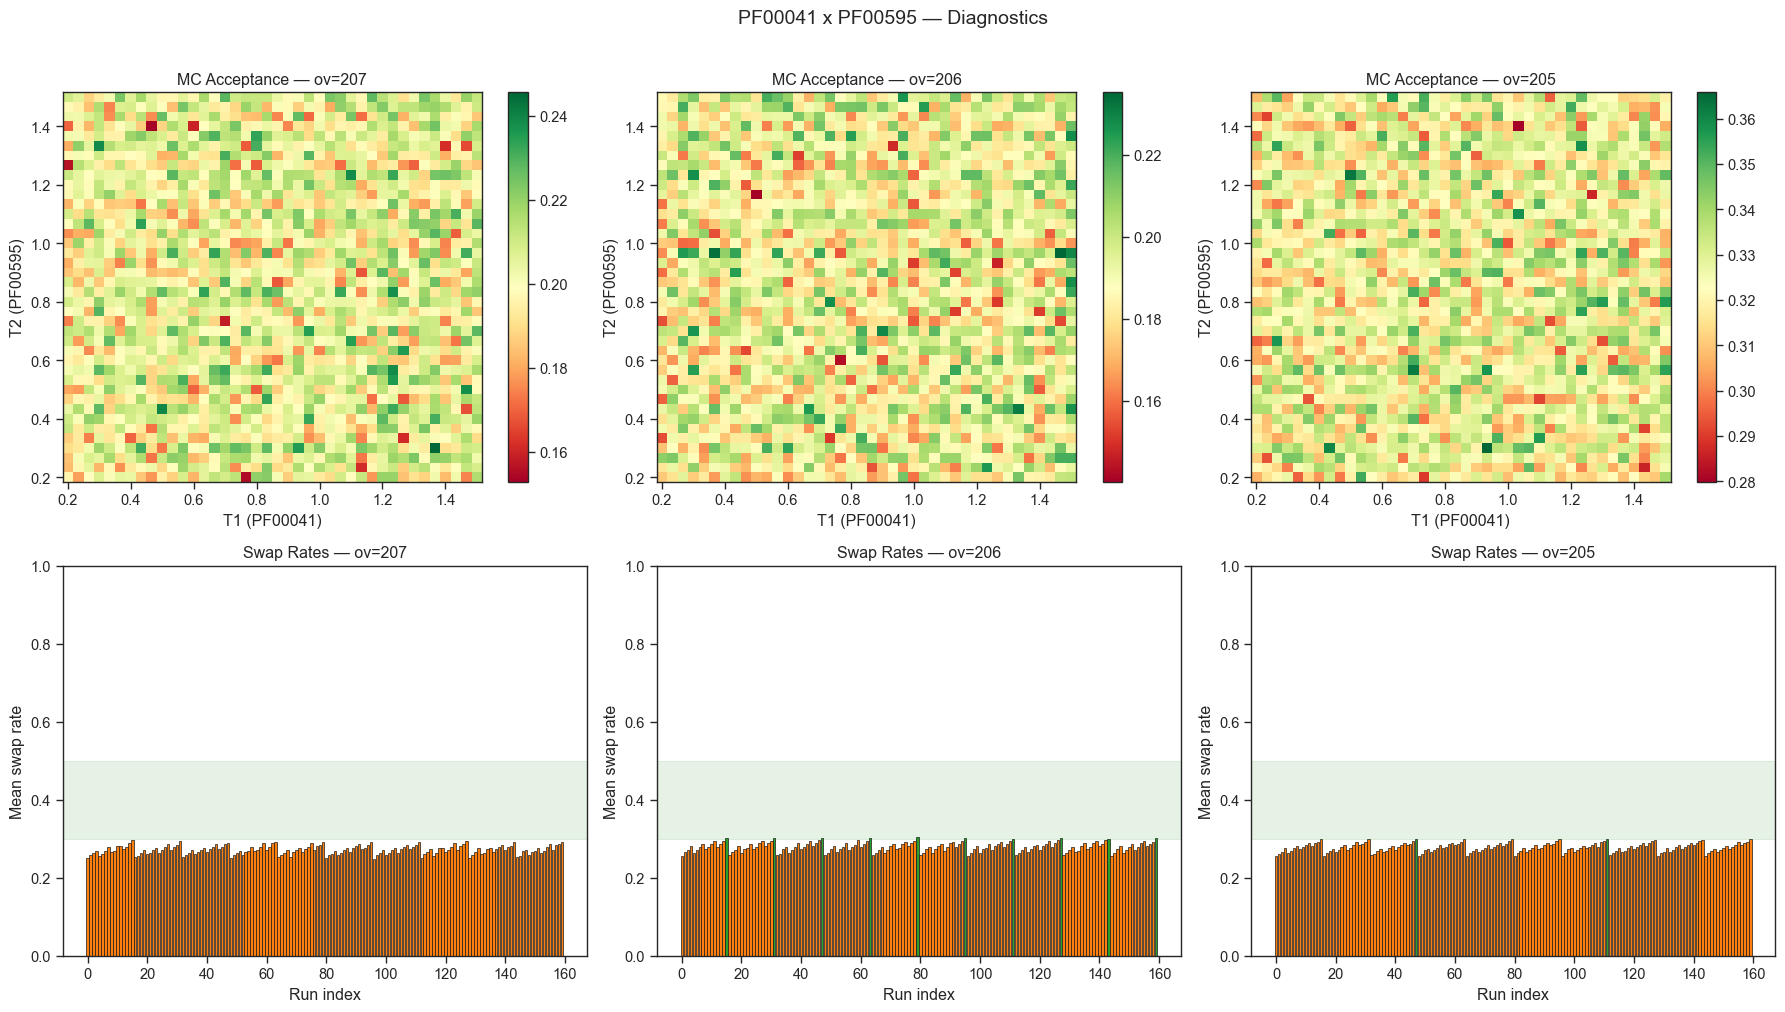

Saved PF00041_PF00595_diagnostics.png


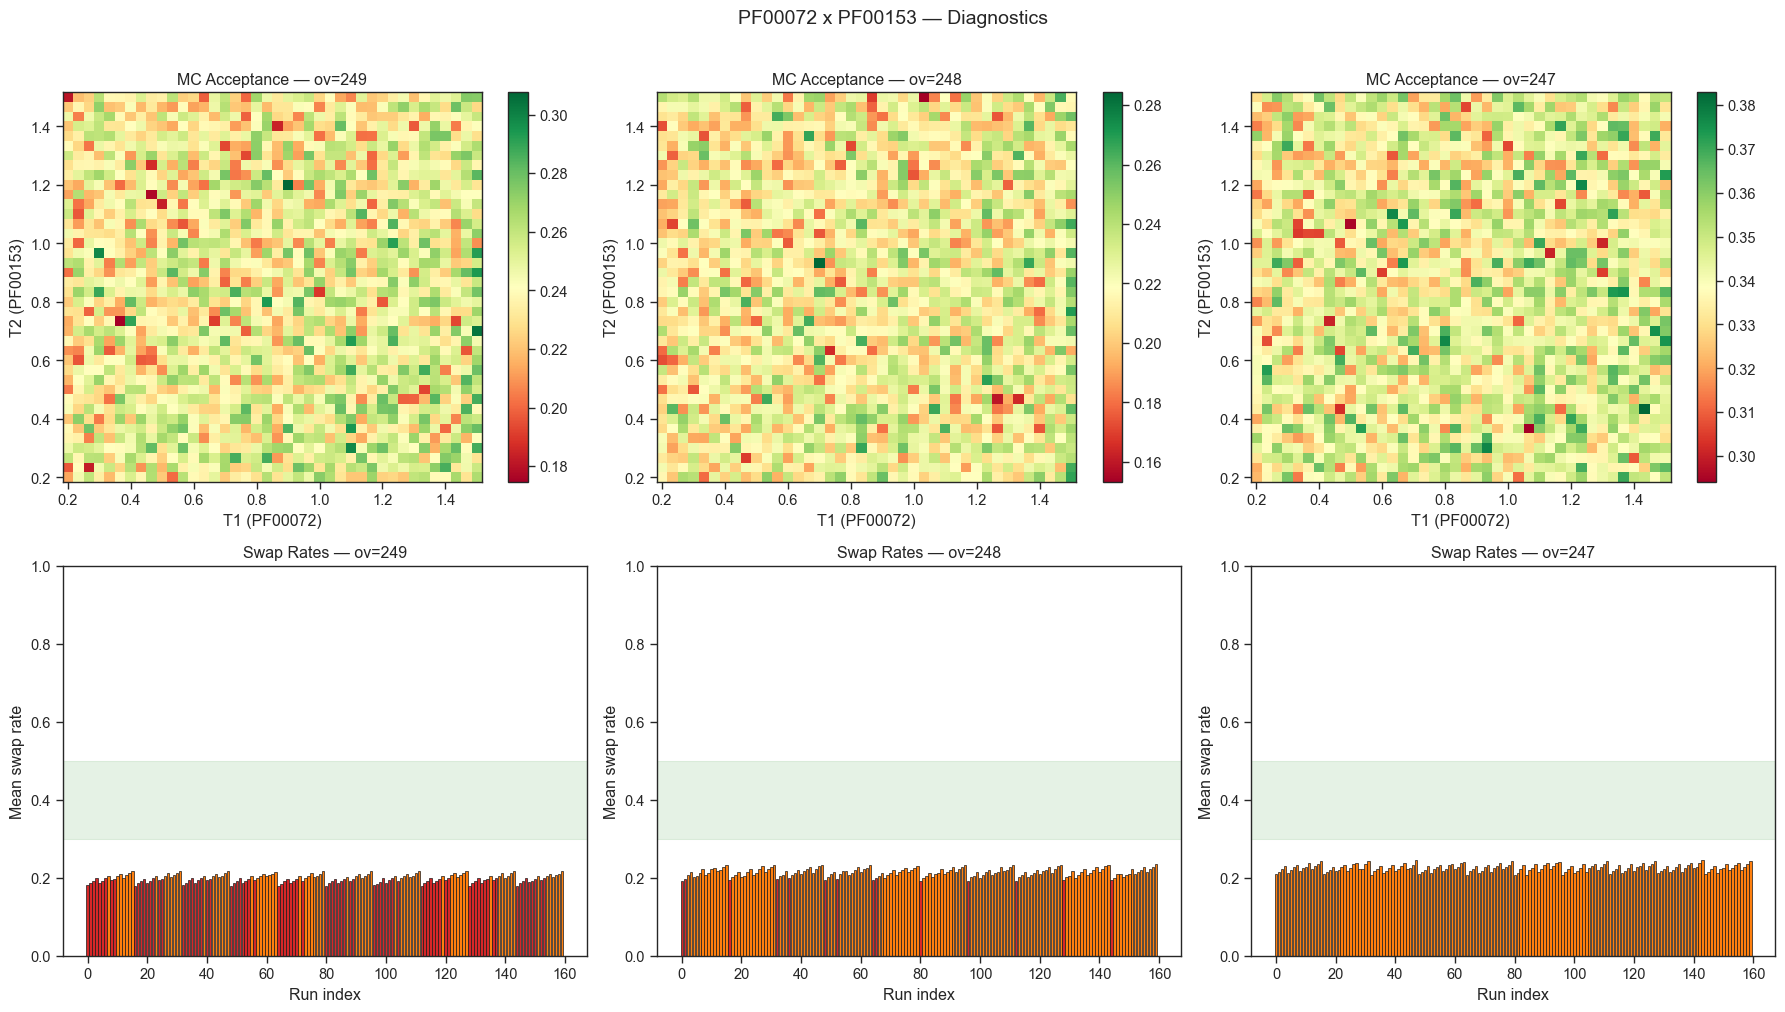

Saved PF00072_PF00153_diagnostics.png


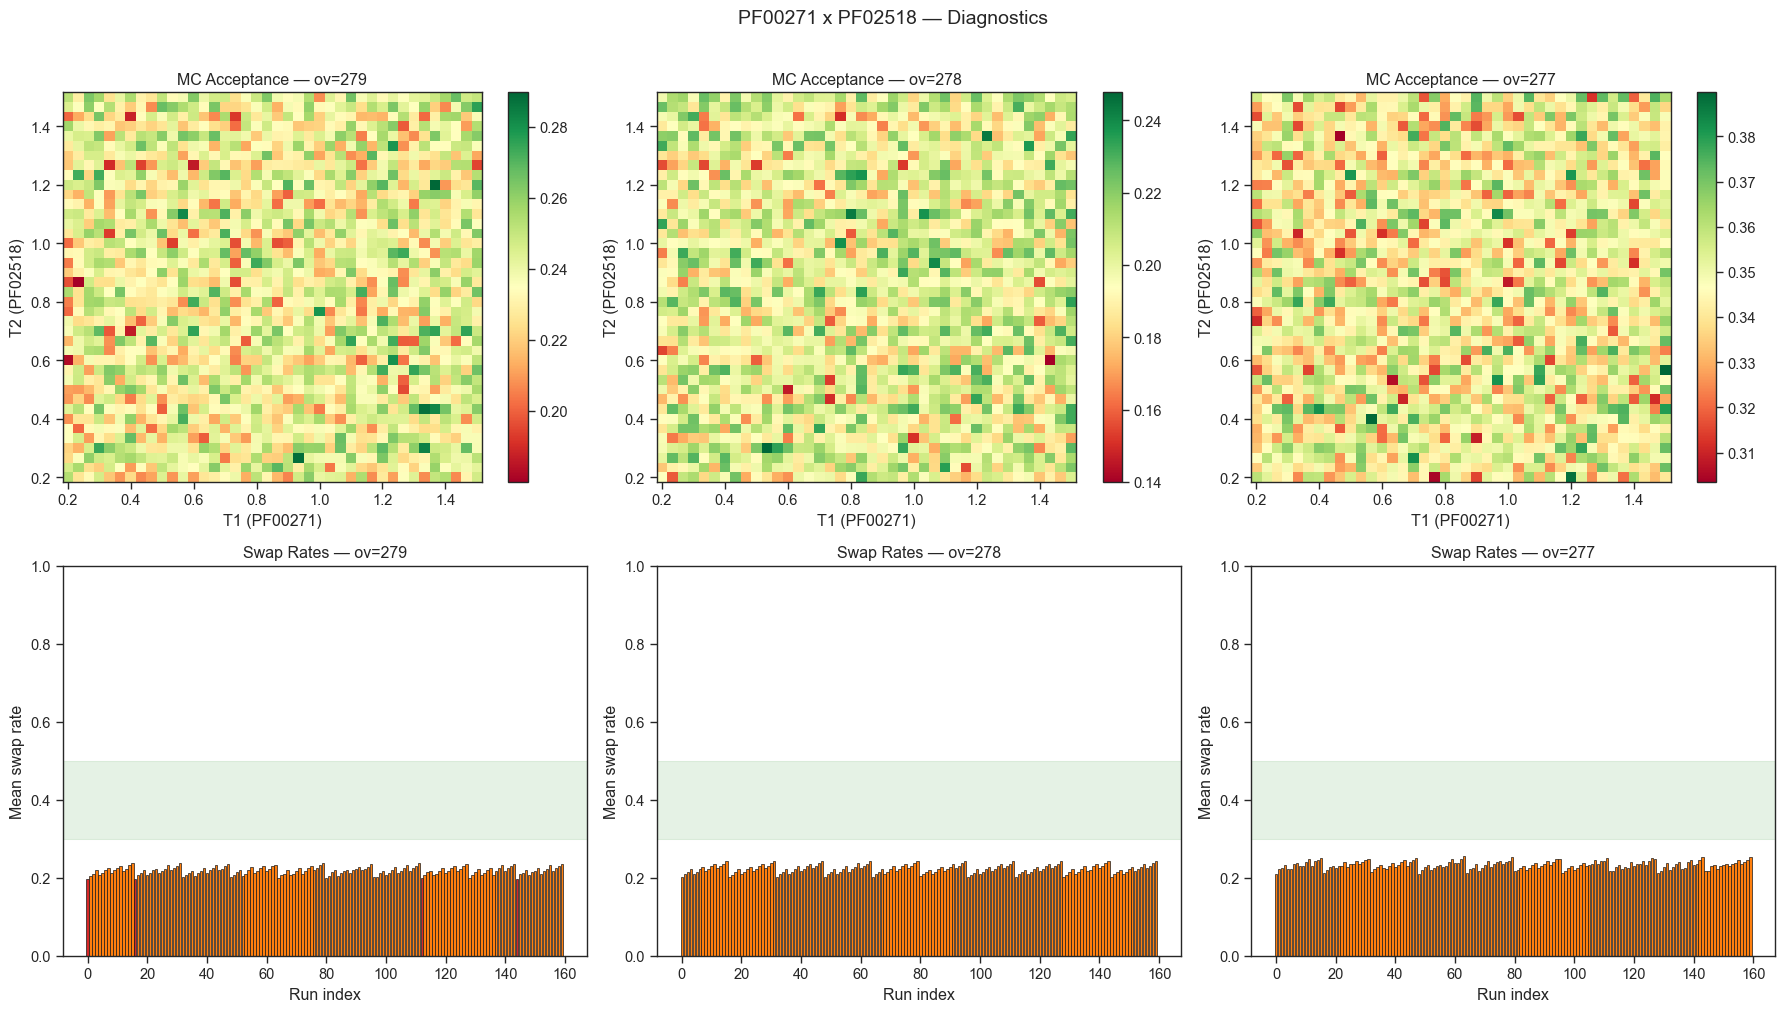

Saved PF00271_PF02518_diagnostics.png


In [8]:
# === Cell 8: Acceptance rate and swap diagnostics ===

for key, d in results.items():
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    overlaps = d['overlap_lengths']

    fig, axes = plt.subplots(2, len(overlaps), figsize=(6 * len(overlaps), 10))
    if len(overlaps) == 1:
        axes = axes[:, np.newaxis]

    for col, ov in enumerate(overlaps):
        ov = int(ov)
        T1 = d[f'T1_fine_{ov}']
        T2 = d[f'T2_fine_{ov}']
        acc_mean = d[f'acc_mean_{ov}']

        # Acceptance heatmap
        ax = axes[0, col]
        pcm = ax.pcolormesh(T1, T2, acc_mean, cmap='RdYlGn', shading='auto')
        ax.set_xlabel(f'T1 ({pf1})')
        ax.set_ylabel(f'T2 ({pf2})')
        ax.set_title(f'MC Acceptance — ov={ov}')
        fig.colorbar(pcm, ax=ax)

        # Swap rates bar chart
        ax = axes[1, col]
        swap_key = f'swap_mean_swap_rates_{ov}'
        if swap_key in d:
            swap_rates = d[swap_key]
            colors = ['#2ca02c' if 0.3 <= s <= 0.5 else '#d62728' if s < 0.2 or s > 0.7
                      else '#ff7f0e' for s in swap_rates]
            ax.bar(range(len(swap_rates)), swap_rates, color=colors,
                   edgecolor='k', linewidth=0.5)
            ax.axhspan(0.3, 0.5, alpha=0.1, color='green')
            ax.set_xlabel('Run index')
            ax.set_ylabel('Mean swap rate')
            ax.set_ylim(0, 1)
        ax.set_title(f'Swap Rates — ov={ov}')

    fig.suptitle(f'{pf1} x {pf2} — Diagnostics', fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, f'{key}_diagnostics.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {key}_diagnostics.png")

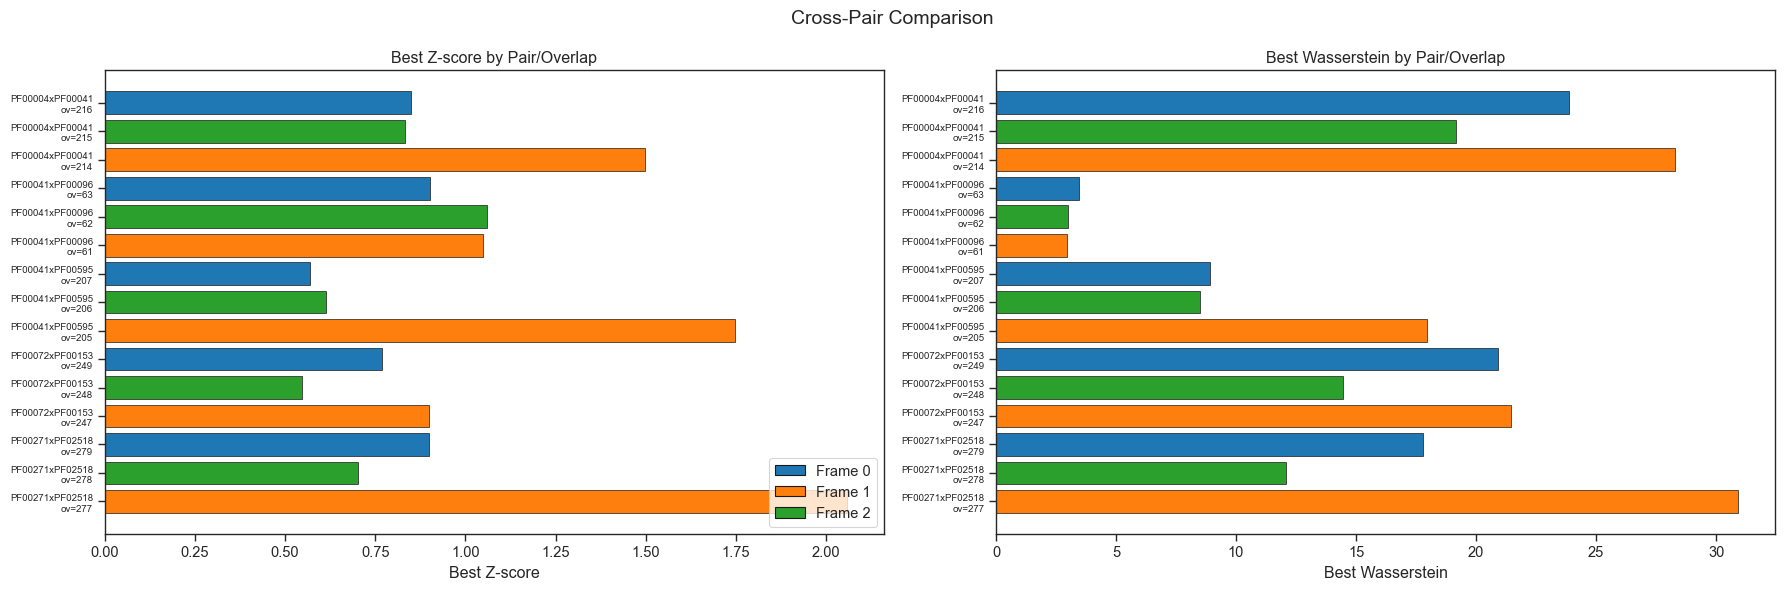

Saved cross_pair_comparison.png


In [37]:
# === Cell 9: Cross-pair comparison — best metrics across all pairs ===

# Collect best metrics per pair (using first overlap / max overlap)
comparison_rows = []
for key, d in results.items():
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    for ov in d['overlap_lengths']:
        ov = int(ov)
        z_mean = d[f'z_mean_{ov}']
        wass_mean = d[f'wass_mean_{ov}']
        comparison_rows.append({
            'pair': f"{pf1}\nx\n{pf2}",
            'pair_short': f"{pf1}x{pf2}",
            'overlap': ov,
            'frame': ov % 3,
            'best_z': float(z_mean.min()),
            'best_wass': float(wass_mean.min()),
        })

if len(comparison_rows) > 1:
    df_comp = pd.DataFrame(comparison_rows)

    fig, axes = plt.subplots(1, 2, figsize=(max(12, len(comparison_rows) * 1.2), 6))

    # Best z-score per pair/overlap
    ax = axes[0]
    labels = [f"{r['pair_short']}\nov={r['overlap']}" for _, r in df_comp.iterrows()]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # one per frame
    bar_colors = [colors[r['frame']] for _, r in df_comp.iterrows()]
    ax.barh(range(len(df_comp)), df_comp['best_z'], color=bar_colors, edgecolor='k', lw=0.5)
    ax.set_yticks(range(len(df_comp)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('Best Z-score')
    ax.set_title('Best Z-score by Pair/Overlap')
    ax.invert_yaxis()

    # Best Wasserstein per pair/overlap
    ax = axes[1]
    ax.barh(range(len(df_comp)), df_comp['best_wass'], color=bar_colors, edgecolor='k', lw=0.5)
    ax.set_yticks(range(len(df_comp)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('Best Wasserstein')
    ax.set_title('Best Wasserstein by Pair/Overlap')
    ax.invert_yaxis()

    # Legend for frames
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[i], edgecolor='k', label=f'Frame {i}')
                       for i in range(3)]
    axes[0].legend(handles=legend_elements, loc='lower right')

    fig.suptitle('Cross-Pair Comparison', fontsize=14)
    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, 'cross_pair_comparison.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved cross_pair_comparison.png")
else:
    print("Need more than 1 completed pair for cross-pair comparison.")